<center>

<font face="Cambria" size=6>ASYJ Nexus IA</font>

<font face="Cambria" size=4>Hackathon 2026</font>

<font face="Cambria" size=4>Samsung Innovation Campus</font>

---

<font face="Cambria" size=6><b>Predicción de demanda, inventario y comportamiento comercial</b></font>

<font face="Cambria" size=4><i>RetailMind Challenge</i></font>

---

<font face="Cambria" size=3>
Yineth Daniela Botina Puerres &nbsp;·&nbsp; Johann Smith Rivera Montoya &nbsp;·&nbsp; Sahara Benavides Pasmino
</font>

<font face="Cambria" size=2>Universidad Rosario Central · Bogotá · 2026</font>

</center>

<center>
<font face="Cambria" size=6><b>Índice</b></font>
</center>

---

<font face="Cambria" size=3>

0 · Instalación y configuración

1 · Imports y rutas

2 · Cargue de datos

3 · Exploración inicial

4 · Limpieza y preparación de datos

5 · Reporte de limpieza

6 · Análisis exploratorio — EDA

&nbsp;&nbsp;&nbsp;&nbsp; 6.1 · EDA complementario

7 · Modelo predictivo supervisado

&nbsp;&nbsp;&nbsp;&nbsp; 7.1 · Comparación multi-modelo: RF, Árbol, GBM y XGBoost

&nbsp;&nbsp;&nbsp;&nbsp; 7.2 · Auditoría estadística y backtesting rolling-origin del ganador

&nbsp;&nbsp;&nbsp;&nbsp; 7.3 · Entrenamiento final y validación del campeón

&nbsp;&nbsp;&nbsp;&nbsp; 7.4 · Respuestas a las preguntas del reto

&nbsp;&nbsp;&nbsp;&nbsp; 7.5 · Recomendaciones de inventario y despacho

8 · Exportables para dashboard y conclusiones

&nbsp;&nbsp;&nbsp;&nbsp; 8.1 · Interpretación por fase

</font>

<center>
<font face="Cambria" size=6><b>Resumen metodológico</b></font>
</center>

---

<font face="Cambria" size=3>

El flujo garantiza que el test sea una evaluación final cerrada, sin fuga de información entre etapas.

| Etapa | Qué se hace | Resultado |
|---|---|---|
| **Preparación** | Convertir semanas a formato largo, marcar ceros futuros, conservar devoluciones | Base mensual confiable |
| **EDA** | Tendencias, estacionalidad, Pareto, inventario y comportamiento de clientes | Hallazgos para negocio |
| **Modelado** | Comparar RF, Árbol, GBM y XGBoost evaluando solo en validation | Modelo campeón |
| **Auditoría** | Backtesting rolling-origin de 6 folds y comparación contra baselines | Evidencia de robustez |
| **Acción** | Predicciones, churn, crecimiento y prioridad de despacho | Archivos para dashboard |

</font>

<center>
<font face="Cambria" size=5><b>0. Instalación y configuración</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Preparar el entorno para que el notebook corra igual en local o en Colab.

**Qué se revisa.** Paquetes necesarios, rutas base y carpetas de salida.

</font>

In [3]:
# Instala paquetes faltantes cuando el notebook corre en Colab.
import sys, subprocess, importlib.util

REQUIRED = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly', 'sklearn', 'xgboost', 'joblib']
PIP_NAMES = {'sklearn': 'scikit-learn'}

missing = [m for m in REQUIRED if importlib.util.find_spec(m) is None]
if missing:
    print('Instalando librerias faltantes:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + [PIP_NAMES.get(m, m) for m in missing])
else:
    print('Librerias verificadas.')

Librerias verificadas.


<center>
<font face="Cambria" size=5><b>1. Imports y rutas</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Cargar librerías, ubicar los CSV y organizar los outputs en tres carpetas: `csv`, `imagenes` y `otros`.

**Salida.** Rutas listas para leer datos y guardar resultados del proyecto.

</font>

In [4]:
# Carga librerias y define rutas de entrada y salida.
from pathlib import Path
import gc
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import joblib

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder

# Montar en Drive
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# Rutas
# La carpeta compartida debe estar añadida a "Mi unidad" desde Drive.
# Ruta estándar después de montarla:
DRIVE_FOLDER = Path('/content/drive/MyDrive/Hackathon SIC 2026')

if IN_COLAB and DRIVE_FOLDER.exists():
    CSV_DIR = DRIVE_FOLDER
    OUT_DIR = DRIVE_FOLDER / 'outputs'
elif IN_COLAB:
    # Fallback: archivos subidos directamente a /content/
    CSV_DIR = Path('/content')
    OUT_DIR = Path('/content/outputs')
    print(f'  Carpeta Drive no encontrada en {DRIVE_FOLDER}')
    print('   Sube los CSV directamente a /content/ como alternativa.')
else:
    CSV_DIR = Path.cwd()
    OUT_DIR = Path.cwd() / 'outputs'

OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV_DIR = OUT_DIR / 'csv'
OUT_IMG_DIR = OUT_DIR / 'imagenes'
OUT_OTHER_DIR = OUT_DIR / 'otros'
for folder in [OUT_CSV_DIR, OUT_IMG_DIR, OUT_OTHER_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

def output_path(name):
    # Envia cada archivo a la carpeta correcta segun su tipo.
    path = Path(name)
    suffix = path.suffix.lower()
    if suffix == '.csv':
        return OUT_CSV_DIR / path.name
    if suffix in ['.jpg', '.jpeg', '.png']:
        return OUT_IMG_DIR / path.with_suffix('.jpg').name
    return OUT_OTHER_DIR / path.name

# Verificar que los archivos existen
for year in [2023, 2024, 2025]:
    f = CSV_DIR / f'{year}.csv'
    status = '' if f.exists() else 'NO ENCONTRADO'
    print(f'  {status}  {f}')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 10
})
sns.set_theme(style='whitegrid', palette='Set2')

print()
print('Entorno :', 'Colab' if IN_COLAB else 'Local')
print('CSV_DIR :', CSV_DIR)
print('OUT_DIR :', OUT_DIR)
print('CSV_DIR :', OUT_CSV_DIR)
print('IMG_DIR :', OUT_IMG_DIR)
print('OTHER_DIR:', OUT_OTHER_DIR)

Mounted at /content/drive
    /content/drive/MyDrive/Hackathon SIC 2026/2023.csv
    /content/drive/MyDrive/Hackathon SIC 2026/2024.csv
    /content/drive/MyDrive/Hackathon SIC 2026/2025.csv

Entorno : Colab
CSV_DIR : /content/drive/MyDrive/Hackathon SIC 2026
OUT_DIR : /content/drive/MyDrive/Hackathon SIC 2026/outputs
CSV_DIR : /content/drive/MyDrive/Hackathon SIC 2026/outputs/csv
IMG_DIR : /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes
OTHER_DIR: /content/drive/MyDrive/Hackathon SIC 2026/outputs/otros


<center>
<font face="Cambria" size=5><b>2. Cargue de datos</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Leer `2023.csv`, `2024.csv` y `2025.csv` sin mezclar semanas entre años.

**Decisión clave.** Cada archivo se transforma de formato ancho a formato largo para trabajar por cliente, producto, categoría y semana.

</font>

In [5]:
# Lee los CSV por año y los convierte de formato ancho a formato largo.
ARCHIVOS = {year: CSV_DIR / f'{year}.csv' for year in [2023, 2024, 2025]}
ID_COLS = ['Channel', 'Material Description', 'Category']

raw_shapes = []
long_frames = []
quality_load = []

for year, path in ARCHIVOS.items():
    if not path.exists():
        raise FileNotFoundError(f'No se encontro {path}. Sube/copialo en {CSV_DIR}.')

    header = pd.read_csv(path, nrows=0)
    week_cols = [c for c in header.columns if str(c).startswith(str(year))]
    if len(week_cols) != 52:
        print(f'Advertencia: {year} tiene {len(week_cols)} columnas semanales.')

    dtype_map = {c: 'category' for c in ID_COLS}
    dtype_map.update({c: 'string' for c in week_cols})
    df_year = pd.read_csv(path, usecols=ID_COLS + week_cols, dtype=dtype_map)
    raw_shapes.append({'Anio': year, 'filas_raw': len(df_year), 'semanas': len(week_cols)})

    null_values = int(df_year[week_cols].isna().sum().sum())
    # Algunos campos vienen como "1,142.0 " en 2025. Se limpian antes
    df_year[week_cols] = (
        df_year[week_cols]
        .replace({',': '', ' ': ''}, regex=True)
        .apply(pd.to_numeric, errors='coerce')
        .astype('float32')
    )
    df_long_y = df_year.melt(
        id_vars=ID_COLS,
        value_vars=week_cols,
        var_name='YearWeek',
        value_name='Value_raw'
    )
    df_long_y['Anio'] = np.int16(year)
    df_long_y['YearWeek'] = df_long_y['YearWeek'].astype('category')
    df_long_y['Value_raw'] = df_long_y['Value_raw'].astype('float32')
    long_frames.append(df_long_y)

    quality_load.append({
        'Anio': year,
        'filas_raw': len(df_year),
        'filas_long_reales': len(df_long_y),
        'clientes': df_year['Channel'].nunique(),
        'productos': df_year['Material Description'].nunique(),
        'valores_faltantes_originales': null_values,
        'ram_raw_mb': df_year.memory_usage(deep=True).sum() / 1e6,
        'ram_long_mb': df_long_y.memory_usage(deep=True).sum() / 1e6
    })
    print(f'{year}: raw={df_year.shape}, long={df_long_y.shape}, NaN originales={null_values:,}')
    del df_year, df_long_y
    gc.collect()

df_long = pd.concat(long_frames, ignore_index=True)
del long_frames
gc.collect()

quality_load = pd.DataFrame(quality_load)
raw_shapes = pd.DataFrame(raw_shapes)
print('\nFilas long reales:', f'{len(df_long):,}')
display(quality_load)

2023: raw=(43338, 55), long=(2253576, 6), NaN originales=0
2024: raw=(37035, 55), long=(1925820, 6), NaN originales=0
2025: raw=(25239, 55), long=(1312428, 6), NaN originales=0

Filas long reales: 5,491,824


,Anio,filas_raw,filas_long_reales,clientes,productos,valores_faltantes_originales,ram_raw_mb,ram_long_mb
0,2023,43338,2253576,92,1645,0,9.392433,24.999077
1,2024,37035,1925820,80,1386,0,8.003597,21.341161
2,2025,25239,1312428,74,1159,0,5.484175,14.575179


<center>
<font face="Cambria" size=5><b>3. Exploración inicial</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Entender tamaños, columnas, tipos de datos y primeras filas antes de limpiar.

**Uso.** Esta revisión sirve para detectar problemas de estructura antes del análisis.

</font>

In [6]:
# Muestra una primera revision de tamaños, columnas y tipos de datos.
print('=' * 90)
print('ESTRUCTURA GENERAL')
print('=' * 90)
print('Filas long:', f'{len(df_long):,}')
print('Columnas:', df_long.columns.tolist())
print('Clientes unicos:', df_long['Channel'].nunique())
print('Productos unicos:', df_long['Material Description'].nunique())
print('Categorias:', df_long['Category'].cat.categories.tolist() if hasattr(df_long['Category'], 'cat') else sorted(df_long['Category'].unique()))
print('Semanas:', df_long['YearWeek'].nunique(), df_long['YearWeek'].astype(str).min(), '->', df_long['YearWeek'].astype(str).max())
print('\nMuestra:')
display(df_long.head(9))

print('\nTipos de datos:')
display(pd.DataFrame({'dtype': df_long.dtypes.astype(str), 'nulos': df_long.isna().sum()}))

ESTRUCTURA GENERAL
Filas long: 5,491,824
Columnas: ['Channel', 'Material Description', 'Category', 'YearWeek', 'Value_raw', 'Anio']
Clientes unicos: 98
Productos unicos: 2093
Categorias: ['Channel Inv.', 'Cust. Sales', 'Sell-in']
Semanas: 156 202301 -> 202552

Muestra:


,Channel,Material Description,Category,YearWeek,Value_raw,Anio
0,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Sell-in,202301,0.0,2023
1,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Cust. Sales,202301,0.0,2023
2,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",Channel Inv.,202301,0.0,2023
3,CUSTOMER1,"MOBILE,SM-A035M/DS,BLUE,LTC",Sell-in,202301,0.0,2023
4,CUSTOMER1,"MOBILE,SM-A035M/DS,BLUE,LTC",Cust. Sales,202301,0.0,2023
5,CUSTOMER1,"MOBILE,SM-A035M/DS,BLUE,LTC",Channel Inv.,202301,0.0,2023
6,CUSTOMER1,"MOBILE,SM-A035M/DS,BLACK,LTC",Sell-in,202301,0.0,2023
7,CUSTOMER1,"MOBILE,SM-A035M/DS,BLACK,LTC",Cust. Sales,202301,0.0,2023
8,CUSTOMER1,"MOBILE,SM-A035M/DS,BLACK,LTC",Channel Inv.,202301,0.0,2023



Tipos de datos:


,dtype,nulos
Channel,object,0
Material Description,object,0
Category,category,0
YearWeek,object,0
Value_raw,float32,0
Anio,int16,0


<center>
<font face="Cambria" size=5><b>4. Limpieza y preparación de datos</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Convertir valores a número, marcar semanas futuras sin dato real, identificar devoluciones y conservar ceros válidos.

**Regla del reto.** No se eliminan registros originales: se usan banderas para documentar el tratamiento.

</font>

In [7]:
# Limpia valores númericos y marca ceros futuros, devoluciones y ceros reales.
nan_originales = int(df_long['Value_raw'].isna().sum())
df_long['Value'] = df_long['Value_raw'].astype('float32')
df_long.drop(columns=['Value_raw'], inplace=True)

yw = df_long['YearWeek'].astype(str)
df_long['Year_num'] = yw.str[:4].astype('int16')
df_long['Week_num'] = yw.str[4:].astype('int8')
df_long['Date'] = pd.to_datetime(
    df_long['Year_num'].astype(str) + '-W' + df_long['Week_num'].astype(str).str.zfill(2) + '-1',
    format='%G-W%V-%u',
    errors='coerce'
)
df_long['Month'] = df_long['Date'].dt.to_period('M')

# Última semana con actividad real por año. Las semanas posteriores totalmente vacias se marcan como futuro
last_active = {}
for year in sorted(df_long['Anio'].unique()):
    active = df_long.loc[(df_long['Anio'] == year) & df_long['Value'].notna() & (df_long['Value'] != 0), 'YearWeek'].astype(str)
    last_active[int(year)] = active.max() if len(active) else f'{int(year)}00'

df_long['is_future_zero'] = (
    (df_long['Value'].isna() | (df_long['Value'] == 0)) &
    (df_long['YearWeek'].astype(str) > df_long['Anio'].map(last_active))
).fillna(False).astype('int8')
df_long['is_missing_observed'] = (df_long['Value'].isna() & (df_long['is_future_zero'] == 0)).astype('int8')
df_long['is_return'] = (df_long['Value'] < 0).fillna(False).astype('int8')
df_long['is_zero_real'] = ((df_long['Value'] == 0) & (df_long['is_future_zero'] == 0)).fillna(False).astype('int8')

df_long['Product_Type'] = df_long['Material Description'].astype(str).str.split(',').str[0].str.strip().astype('category')
df_long = df_long.rename(columns={'Channel': 'Cliente', 'Material Description': 'Producto', 'Category': 'Categoria'})

quality_summary = {
    'registros_long_reales': int(len(df_long)),
    'nan_originales_preservados': nan_originales,
    'fechas_invalidas': int(df_long['Date'].isna().sum()),
    'valores_positivos': int((df_long['Value'] > 0).sum()),
    'valores_negativos_devoluciones': int(df_long['is_return'].sum()),
    'ceros_reales': int(df_long['is_zero_real'].sum()),
    'faltantes_en_periodo_observado': int(df_long['is_missing_observed'].sum()),
    'ceros_futuros_no_observados': int(df_long['is_future_zero'].sum()),
    'ultimo_periodo_activo_por_anio': last_active
}
display(pd.Series(quality_summary, name='valor'))

# Para modelado se excluyen solo semanas futuras no observadas; no se elimina informacion real del dataset original.
df_work = df_long[df_long['is_future_zero'] == 0].copy()
print('df_work:', f'{len(df_work):,}', 'filas')

,valor
registros_long_reales,5491824
nan_originales_preservados,0
fechas_invalidas,0
valores_positivos,1180390
valores_negativos_devoluciones,13420
ceros_reales,3818473
faltantes_en_periodo_observado,0
ceros_futuros_no_observados,479541
ultimo_periodo_activo_por_anio,"{2023: '202352', 2024: '202452', 2025: '202533'}"


df_work: 5,012,283 filas


In [8]:
# Agrupa la informacion semanal a nivel mensual por cliente y producto.
# Pivot semanal: una fila por cliente-producto-semana
df_pivot = df_work.pivot_table(
    index=['Cliente', 'Producto', 'Product_Type', 'Date', 'Month', 'Anio', 'YearWeek'],
    columns='Categoria',
    values='Value',
    aggfunc='sum',
    observed=True
).reset_index()
df_pivot.columns.name = None
df_pivot = df_pivot.rename(columns={'Sell-in': 'Sell_in', 'Cust. Sales': 'Cust_Sales', 'Channel Inv.': 'Channel_Inv'})

for col in ['Sell_in', 'Cust_Sales']:
    if col not in df_pivot.columns:
        df_pivot[col] = 0.0
    df_pivot[col] = df_pivot[col].fillna(0).astype('float32')

if 'Channel_Inv' not in df_pivot.columns:
    df_pivot['Channel_Inv'] = np.nan
df_pivot['Channel_Inv'] = df_pivot['Channel_Inv'].astype('float32')

df_pivot = df_pivot.sort_values(['Cliente', 'Producto', 'Date'])

monthly = (
    df_pivot
    .sort_values(['Cliente', 'Producto', 'Date'])
    .groupby(['Cliente', 'Producto', 'Product_Type', 'Month', 'Anio'], observed=True)
    .agg(
        Sell_in=('Sell_in', 'sum'),
        Cust_Sales=('Cust_Sales', 'sum'),
        Channel_Inv=('Channel_Inv', 'last'),
        weeks_observed=('YearWeek', 'nunique')
    )
    .reset_index()
)
monthly['Month_dt'] = monthly['Month'].dt.to_timestamp()
monthly['mes'] = monthly['Month_dt'].dt.month.astype('int8')
monthly['trimestre'] = monthly['Month_dt'].dt.quarter.astype('int8')

monthly['channel_inv_negative_flag'] = (monthly['Channel_Inv'] < 0).astype('int8')
monthly['Inventory_Turnover'] = (monthly['Cust_Sales'] / (monthly['Channel_Inv'].abs() + 1)).astype('float32')
monthly['Sell_through_rate'] = (monthly['Cust_Sales'] / (monthly['Sell_in'].abs() + 1)).astype('float32')
monthly['Stock_coverage_weeks'] = (monthly['Channel_Inv'] / ((monthly['Cust_Sales'].clip(lower=0) / 4.3) + 1)).astype('float32')
monthly['stockout_flag'] = ((monthly['Channel_Inv'] <= 0) & (monthly['Cust_Sales'] > 0)).astype('int8')

print('df_pivot:', f'{len(df_pivot):,}', 'filas')
print('monthly:', f'{len(monthly):,}', 'filas')
print('Periodo:', monthly['Month_dt'].min().date(), '->', monthly['Month_dt'].max().date())
display(monthly.head())

# Liberar objetos grandes que ya no se requieren
del df_work, df_pivot
gc.collect()

df_pivot: 1,402,189 filas
monthly: 333,381 filas
Periodo: 2023-01-01 -> 2025-08-01


,Cliente,Producto,Product_Type,Month,Anio,Sell_in,Cust_Sales,Channel_Inv,weeks_observed,Month_dt,mes,trimestre,channel_inv_negative_flag,Inventory_Turnover,Sell_through_rate,Stock_coverage_weeks,stockout_flag
0,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",MOBILE,2023-01,2023,0.0,0.0,0.0,5,2023-01-01,1,1,0,0.0,0.0,0.0,0
1,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",MOBILE,2023-02,2023,0.0,0.0,0.0,4,2023-02-01,2,1,0,0.0,0.0,0.0,0
2,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",MOBILE,2023-03,2023,0.0,0.0,0.0,4,2023-03-01,3,1,0,0.0,0.0,0.0,0
3,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",MOBILE,2023-04,2023,0.0,0.0,0.0,4,2023-04-01,4,2,0,0.0,0.0,0.0,0
4,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",MOBILE,2023-05,2023,0.0,0.0,0.0,5,2023-05-01,5,2,0,0.0,0.0,0.0,0


68

<center>
<font face="Cambria" size=5><b>5. Reporte de limpieza</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Resumir la calidad final del dato y dejar una base mensual lista para análisis.

**Salida.** Dataset mensual limpio y reporte simple de calidad.

</font>

In [9]:
# Resume la calidad del dato y guarda la base mensual limpia.
print('=' * 80)
print('REPORTE - RETAILMIND')
print('=' * 80)
print('Archivos procesados: 2023.csv, 2024.csv, 2025.csv')
print('Registros long reales:', f"{quality_summary['registros_long_reales']:,}")
print('NaN originales preservados:', f"{quality_summary['nan_originales_preservados']:,}")
print('Faltantes en periodo observado:', f"{quality_summary['faltantes_en_periodo_observado']:,}")
print('Fechas invalidas:', f"{quality_summary['fechas_invalidas']:,}")
print('Negativos conservados como devoluciones:', f"{quality_summary['valores_negativos_devoluciones']:,}")
print('Ceros futuros/no observados excluidos de EDA/modelado:', f"{quality_summary['ceros_futuros_no_observados']:,}")
print('Ultima semana activa por ano:', quality_summary['ultimo_periodo_activo_por_anio'])
print('\nCobertura final mensual:')
print('Clientes:', monthly['Cliente'].nunique())
print('Productos:', monthly['Producto'].nunique())
print('Tipos de producto:', monthly['Product_Type'].nunique())
print('Meses:', monthly['Month_dt'].nunique())

monthly.to_csv(output_path('dataset_mensual_limpio.csv'), index=False)
print('\nExportados: dataset_mensual_limpio.csv')


REPORTE - RETAILMIND
Archivos procesados: 2023.csv, 2024.csv, 2025.csv
Registros long reales: 5,491,824
NaN originales preservados: 0
Faltantes en periodo observado: 0
Fechas invalidas: 0
Negativos conservados como devoluciones: 13,420
Ceros futuros/no observados excluidos de EDA/modelado: 479,541
Ultima semana activa por ano: {2023: '202352', 2024: '202452', 2025: '202533'}

Cobertura final mensual:
Clientes: 98
Productos: 2093
Tipos de producto: 76
Meses: 32

Exportados: dataset_mensual_limpio.csv


<center>
<font face="Cambria" size=5><b>6. Análisis exploratorio — EDA</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Ver patrones de ventas, inventario, estacionalidad y relación entre variables.

**Lectura esperada.** Identificar qué productos, clientes y períodos explican la mayor parte del negocio.

</font>

In [10]:
# Calcula estadisticas descriptivas y prepara una matriz numerica para analisis.
def savefig(name):
    # Guarda todos los graficos como JPG dentro de outputs/imagenes.
    plt.tight_layout()
    path = output_path(Path(name).with_suffix('.jpg').name)
    plt.savefig(path, dpi=150, bbox_inches='tight', format='jpg', facecolor='white')
    plt.show()
    print('Guardado:', path)

eda_metrics = monthly[['Sell_in', 'Cust_Sales', 'Channel_Inv', 'Inventory_Turnover', 'Sell_through_rate', 'Stock_coverage_weeks']].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
display(eda_metrics)

# Matriz de analisis: filas observaciones mensuales, columnas variables cuantitativas.
X_matrix = monthly[['Sell_in', 'Cust_Sales', 'Channel_Inv', 'Inventory_Turnover', 'Sell_through_rate', 'Stock_coverage_weeks']].fillna(0).to_numpy(dtype='float32')
print('Matriz X para analisis lineal:', X_matrix.shape)
print('Rango aproximado de la matriz:', np.linalg.matrix_rank(X_matrix[:min(len(X_matrix), 20000)]))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Sell_in,333381.0,26.841827,259.305389,-1080.0,0.0,0.0,0.0,0.0,0.000000,60.000000,570.000000,27518.0
Cust_Sales,333381.0,27.182623,215.050964,-1517.0,0.0,0.0,0.0,0.0,2.000000,84.000000,547.000000,17689.0
Channel_Inv,333381.0,56.219894,397.953583,-371.0,0.0,0.0,0.0,0.0,8.000000,172.000000,1183.200000,30594.0
Inventory_Turnover,333381.0,1.986131,38.000523,-10.0,0.0,0.0,0.0,0.0,0.200000,2.473684,29.000000,6776.0
Sell_through_rate,333381.0,10.581278,121.005310,-721.0,0.0,0.0,0.0,0.0,0.972222,23.000000,190.000000,17689.0
Stock_coverage_weeks,333381.0,6.890779,67.827919,-23.0,0.0,0.0,0.0,0.0,4.000000,23.262297,72.535928,11678.0


Matriz X para analisis lineal: (333381, 6)
Rango aproximado de la matriz: 6


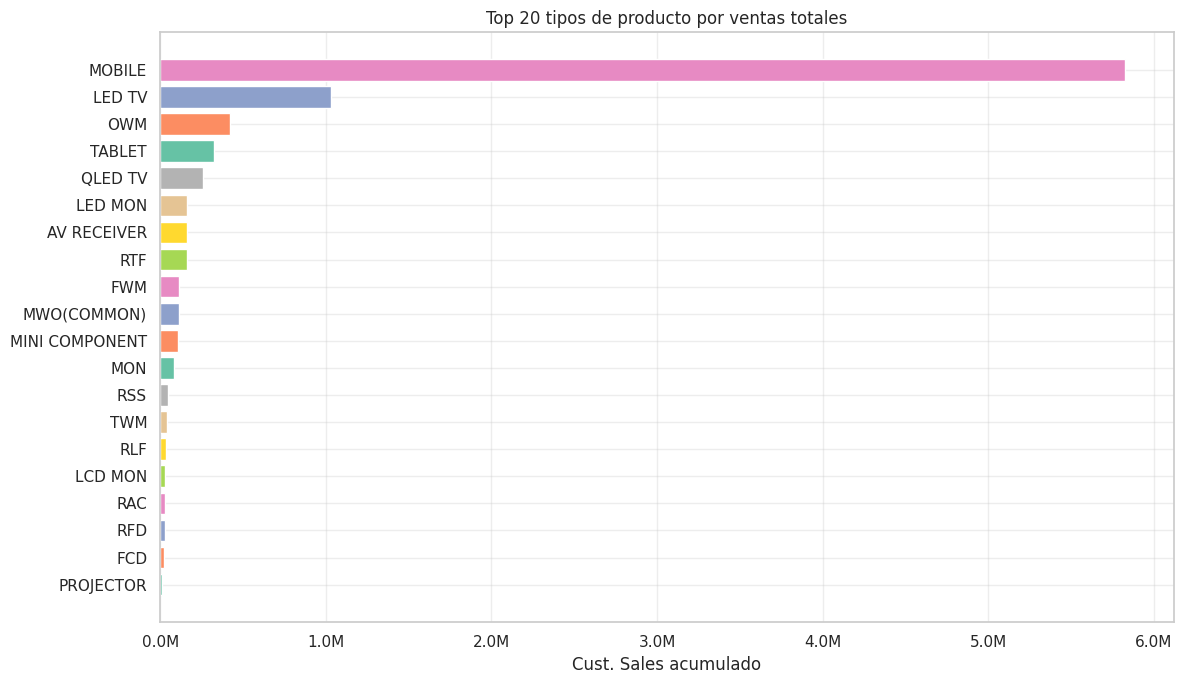

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_01_ventas_tipo_producto.jpg


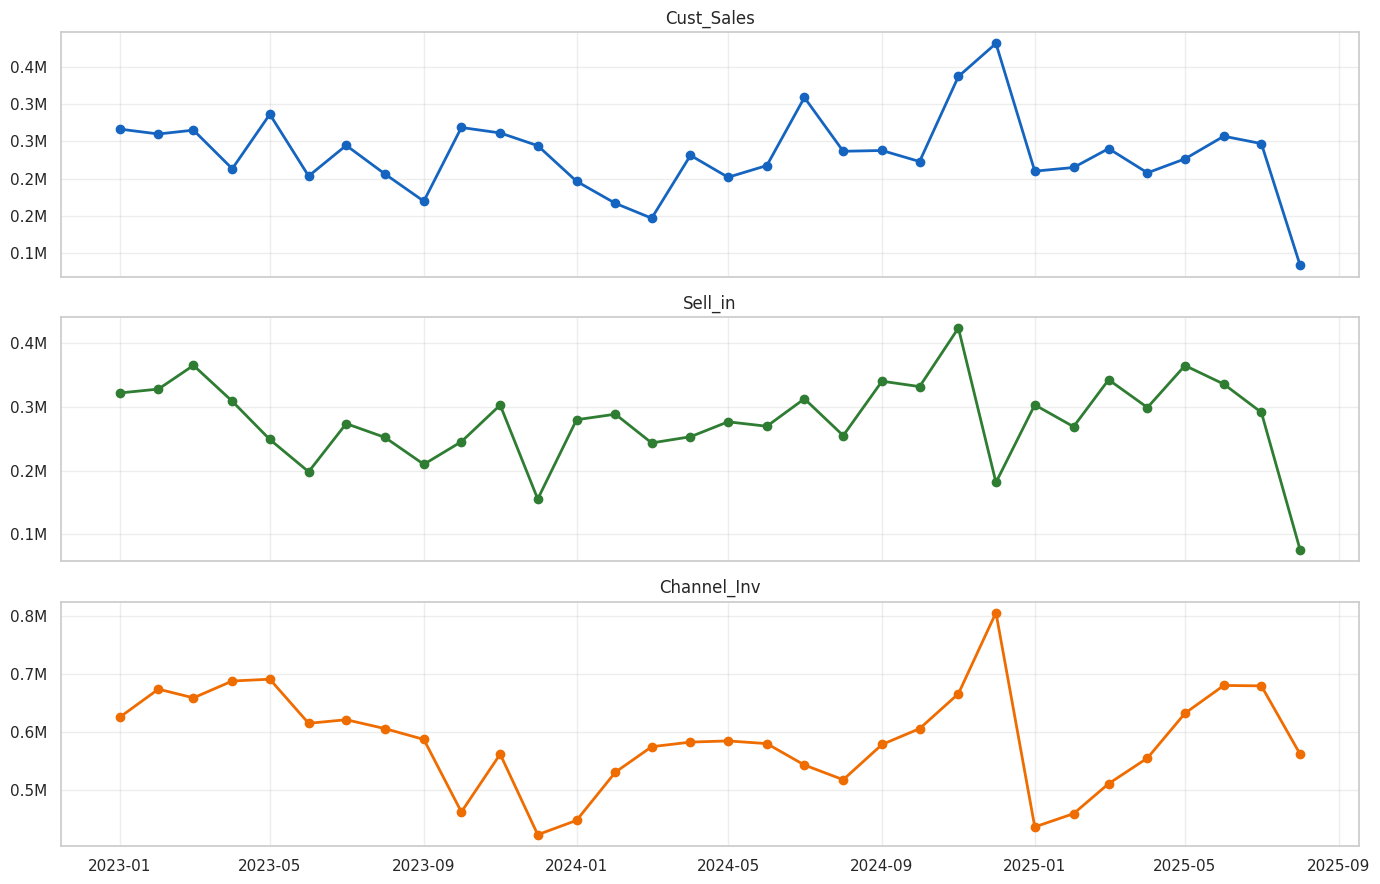

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_02_tendencia_temporal.jpg


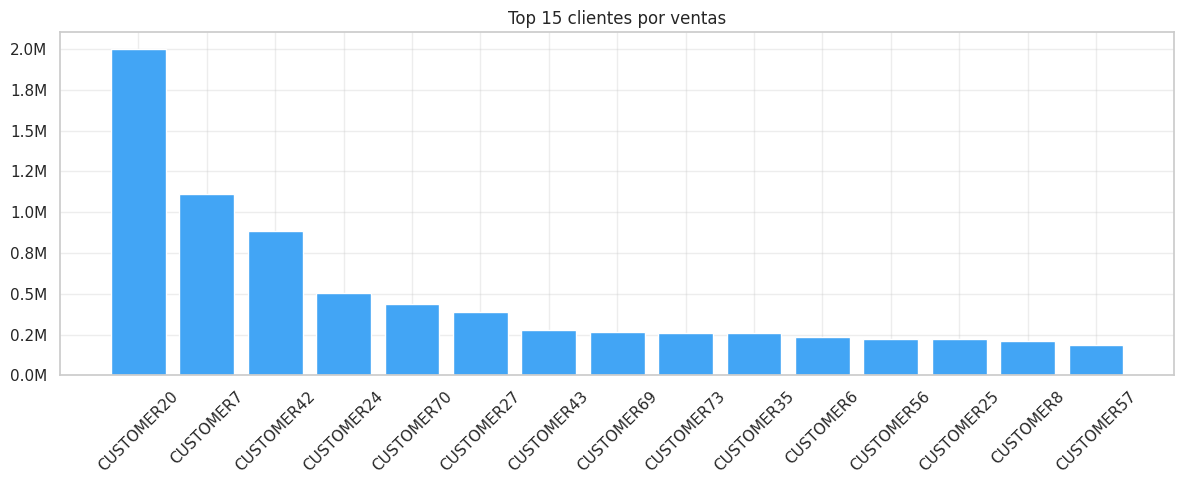

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_03_top_clientes.jpg


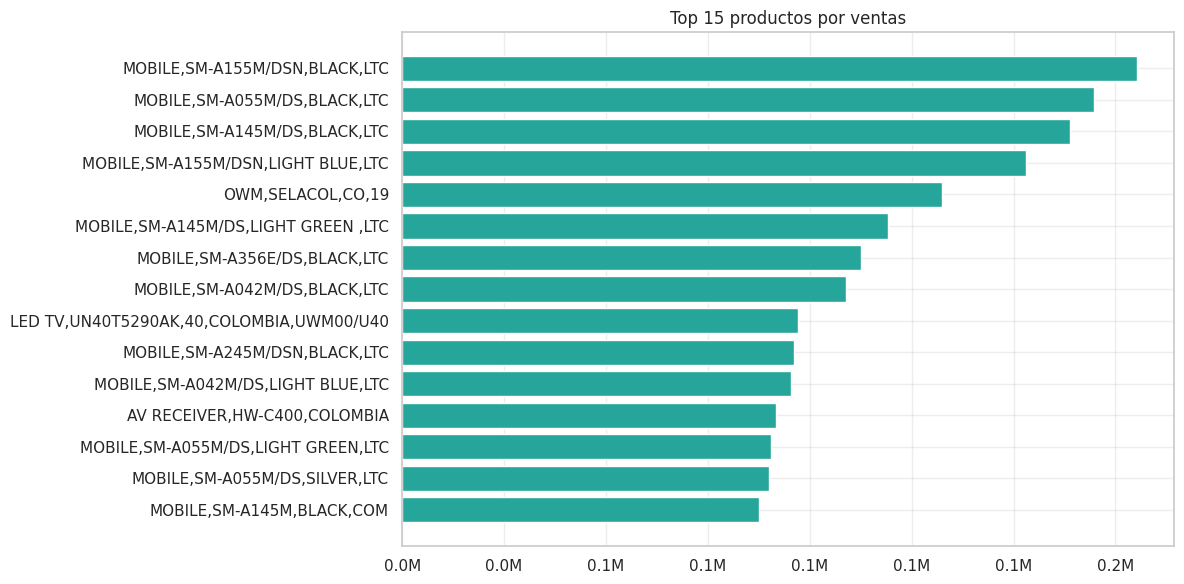

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_04_top_productos.jpg


In [34]:
# Grafico 1: ventas principales por tipo, tiempo, cliente y producto.
ventas_tipo = (
    monthly.groupby('Product_Type', observed=True)['Cust_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index())
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(ventas_tipo['Product_Type'][::-1], ventas_tipo['Cust_Sales'][::-1],
        color=sns.color_palette('Set2', len(ventas_tipo)))
ax.set_title('Top 20 tipos de producto por ventas totales')
ax.set_xlabel('Cust. Sales acumulado')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
savefig('eda_01_ventas_tipo_producto.jpg')

# Grafico 2: tendencia temporal
tendencia = monthly.groupby('Month_dt')[['Cust_Sales', 'Sell_in', 'Channel_Inv']].sum().reset_index()
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, col, color in zip(axes, ['Cust_Sales', 'Sell_in', 'Channel_Inv'], ['#1565C0', '#2E7D32', '#EF6C00']):
    ax.plot(tendencia['Month_dt'], tendencia[col], marker='o', linewidth=2, color=color)
    ax.set_title(col)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
savefig('eda_02_tendencia_temporal.jpg')

# Grafico 3: top clientes
top_clientes = monthly.groupby('Cliente', observed=True)['Cust_Sales'].sum().sort_values(ascending=False).head(15).reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_clientes['Cliente'], top_clientes['Cust_Sales'], color='#42A5F5')
ax.set_title('Top 15 clientes por ventas')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
savefig('eda_03_top_clientes.jpg')

# Grafico 4: top productos
top_productos = monthly.groupby('Producto', observed=True)['Cust_Sales'].sum().sort_values(ascending=False).head(15).reset_index()
top_productos['Producto_short'] = top_productos['Producto'].str.slice(0, 42)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_productos['Producto_short'][::-1], top_productos['Cust_Sales'][::-1], color='#26A69A')
ax.set_title('Top 15 productos por ventas')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
savefig('eda_04_top_productos.jpg')

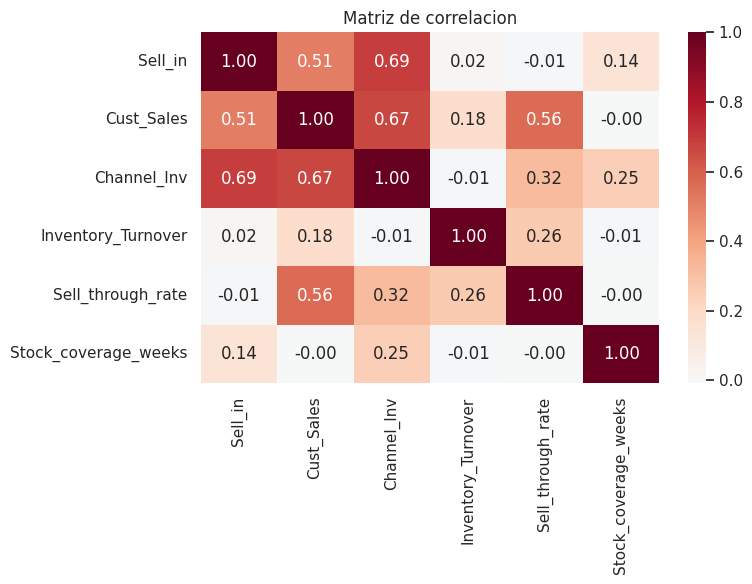

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_05_correlacion.jpg


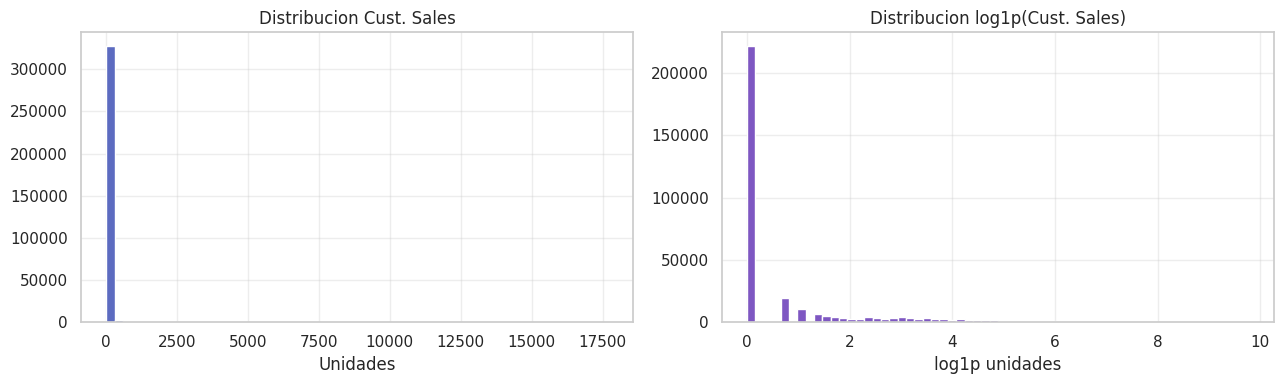

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_06_distribucion_ventas.jpg


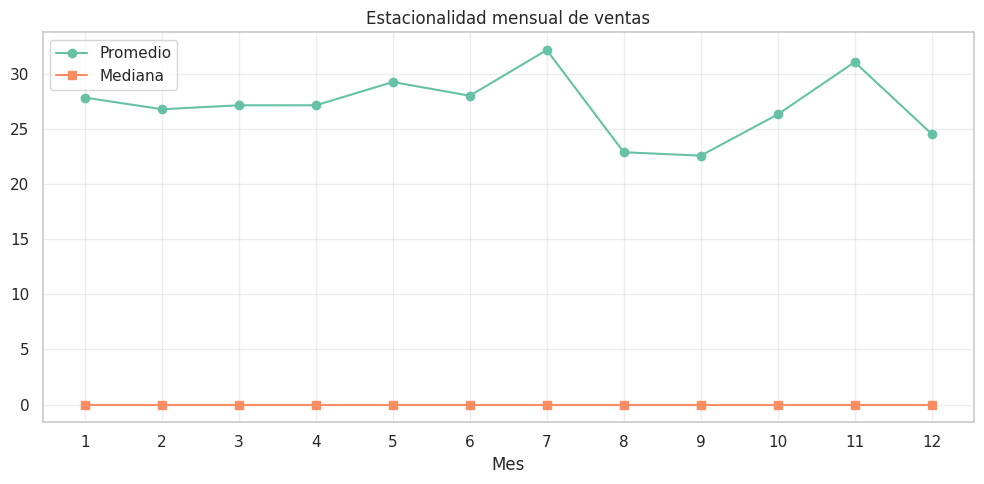

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_07_estacionalidad.jpg


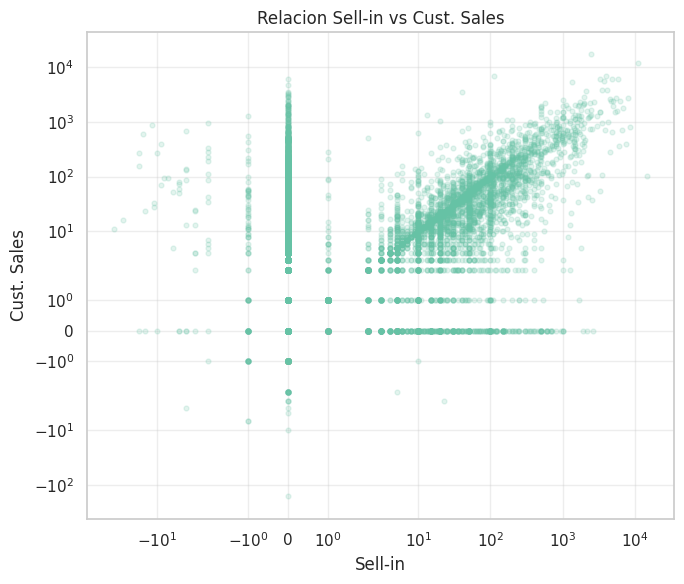

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_08_scatter_sellin_sales.jpg


In [12]:
# Grafico 5: correlaciones, distribuciones, estacionalidad y relacion sell-in vs ventas.
corr_cols = ['Sell_in', 'Cust_Sales', 'Channel_Inv', 'Inventory_Turnover', 'Sell_through_rate', 'Stock_coverage_weeks']
corr = monthly[corr_cols].replace([np.inf, -np.inf], np.nan).fillna(0).corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Matriz de correlacion')
savefig('eda_05_correlacion.jpg')

# Grafico 6: distribucion de ventas demanda intermitente con escala log
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(monthly['Cust_Sales'].clip(lower=0), bins=60, color='#5C6BC0')
axes[0].set_title('Distribucion Cust. Sales')
axes[0].set_xlabel('Unidades')
axes[1].hist(np.log1p(monthly['Cust_Sales'].clip(lower=0)), bins=60, color='#7E57C2')
axes[1].set_title('Distribucion log1p(Cust. Sales)')
axes[1].set_xlabel('log1p unidades')
savefig('eda_06_distribucion_ventas.jpg')

# Grafico 7: estacionalidad mensual
estacionalidad = monthly.groupby('mes')['Cust_Sales'].agg(['mean', 'median', 'sum', 'std']).reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(estacionalidad['mes'], estacionalidad['mean'], marker='o', label='Promedio')
ax.plot(estacionalidad['mes'], estacionalidad['median'], marker='s', label='Mediana')
ax.set_xticks(range(1, 13))
ax.set_title('Estacionalidad mensual de ventas')
ax.set_xlabel('Mes')
ax.legend()
savefig('eda_07_estacionalidad.jpg')

# Grafico 8: scatter sell-in vs ventas
sample_scatter = monthly.sample(min(30000, len(monthly)), random_state=42)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample_scatter['Sell_in'], sample_scatter['Cust_Sales'], alpha=0.18, s=12)
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_title('Relacion Sell-in vs Cust. Sales')
ax.set_xlabel('Sell-in')
ax.set_ylabel('Cust. Sales')
savefig('eda_08_scatter_sellin_sales.jpg')

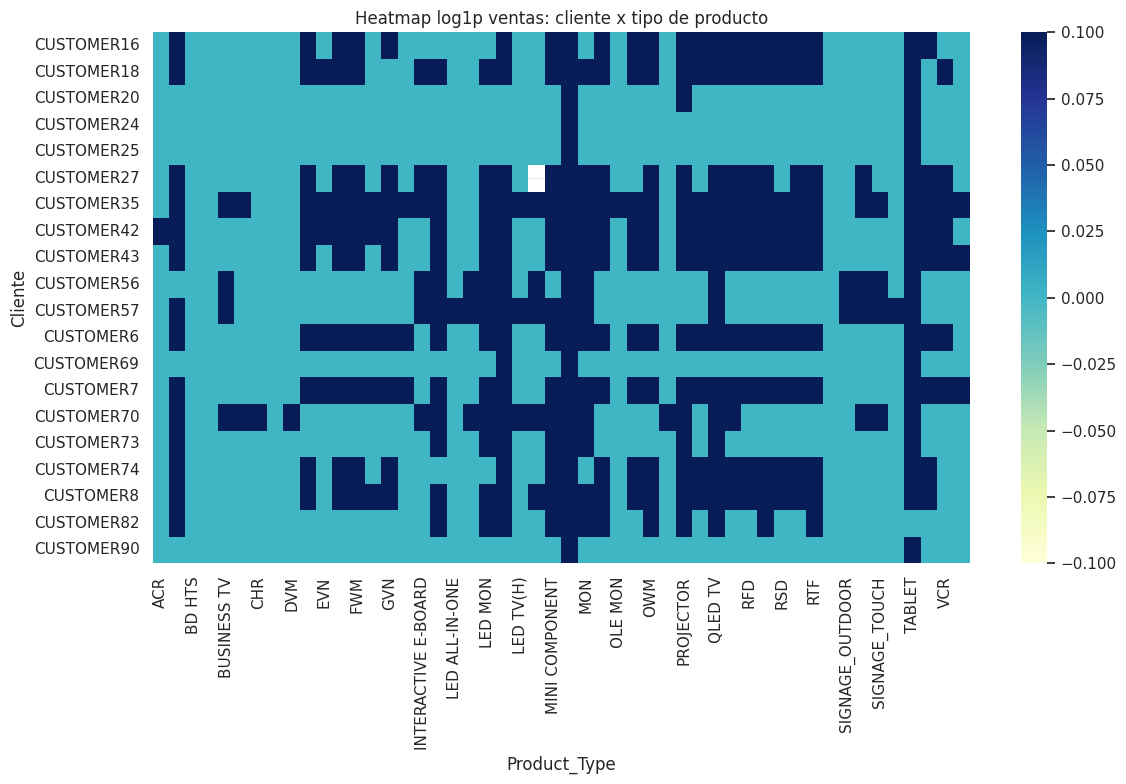

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_09_heatmap_cliente_tipo.jpg


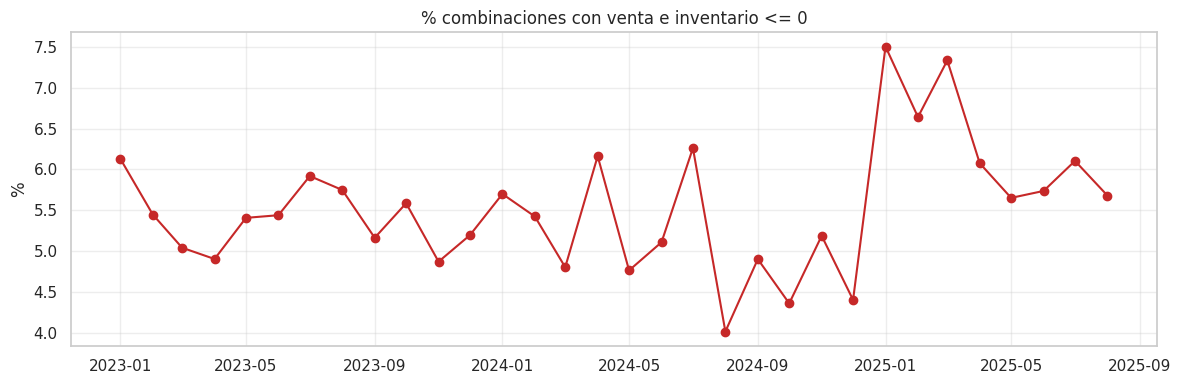

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_10_stockout_rate.jpg
Umbral IQR ventas: 5.0
Outliers ventas: 65499 (19.65%)


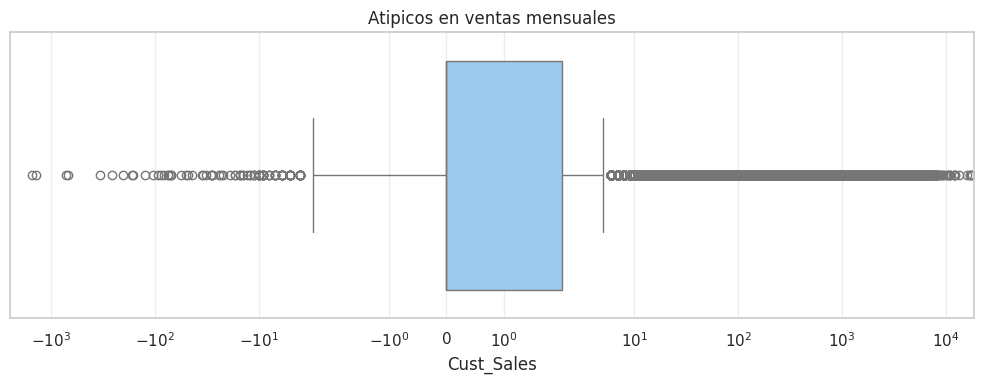

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_12_outliers_boxplot.jpg


In [13]:
 # Grafico 9: patrones por cliente, producto y riesgo historico de inventario.
top_clientes_20 = monthly.groupby('Cliente', observed=True)['Cust_Sales'].sum().nlargest(20).index
heat = monthly[monthly['Cliente'].isin(top_clientes_20)].pivot_table(
    index='Cliente', columns='Product_Type', values='Cust_Sales', aggfunc='sum', observed=True, fill_value=0)
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(np.log1p(heat), cmap='YlGnBu', ax=ax)
ax.set_title('Heatmap log1p ventas: cliente x tipo de producto')
savefig('eda_09_heatmap_cliente_tipo.jpg')

# Grafico 10: stockouts y cobertura
stockout = monthly.groupby('Month_dt')['stockout_flag'].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stockout['Month_dt'], stockout['stockout_flag'] * 100, marker='o', color='#C62828')
ax.set_title('% combinaciones con venta e inventario <= 0')
ax.set_ylabel('%')
savefig('eda_10_stockout_rate.jpg')

# Grafico 11: YoY por tipo de producto
yoy = monthly.groupby(['Anio', 'Product_Type'], observed=True)['Cust_Sales'].sum().reset_index()
fig = px.line(yoy, x='Anio', y='Cust_Sales', color='Product_Type', markers=True, title='Ventas anuales por tipo de producto')

# Grafico 12: outliers por IQR
q1, q3 = monthly['Cust_Sales'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
monthly['outlier_sales_iqr'] = (monthly['Cust_Sales'] > upper).astype('int8')
print('Umbral IQR ventas:', upper)
print('Outliers ventas:', int(monthly['outlier_sales_iqr'].sum()), f"({monthly['outlier_sales_iqr'].mean()*100:.2f}%)")
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=monthly, x='Cust_Sales', ax=ax, color='#90CAF9')
ax.set_xscale('symlog')
ax.set_title('Atipicos en ventas mensuales')
savefig('eda_12_outliers_boxplot.jpg')

<center>
<font face="Cambria" size=5><b>6.1 EDA complementario</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Profundizar en tendencia temporal, Pareto 80/20, clientes que crecen o caen, y riesgo histórico de inventario.

**Salida.** Gráficos e indicadores que luego alimentan el dashboard y la presentación.

</font>

,Anio,Cust_Sales,Sell_in,Channel_Inv,participacion_ventas_%
0,2023,3489256.0,3210417.0,48.798222,38.503536
1,2024,3449154.0,3441891.0,54.399391,38.061016
2,2025,2123760.0,2296247.0,76.925095,23.435446


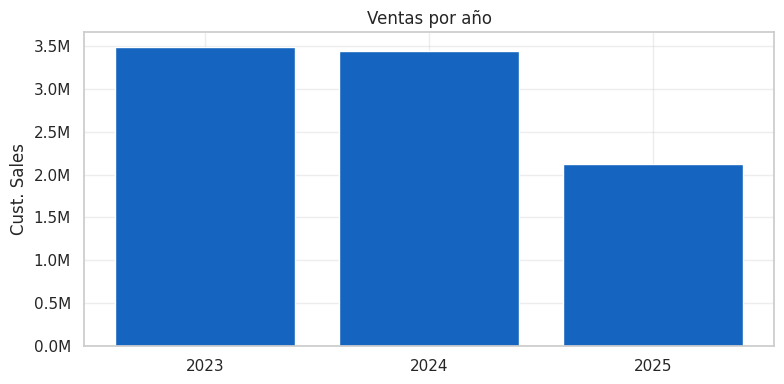

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_13_ventas_por_año.jpg


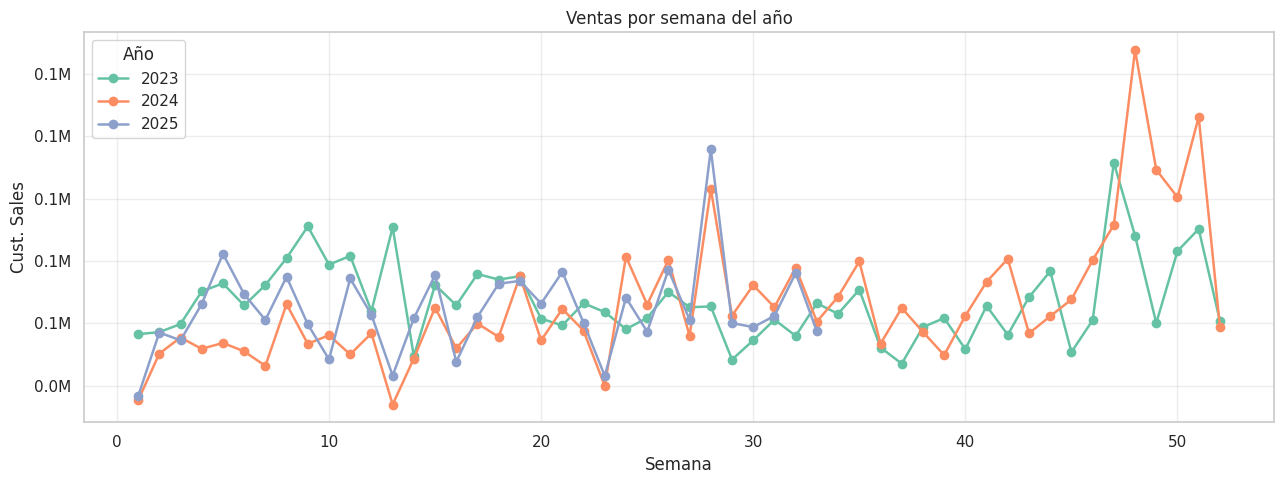

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_14_ventas_por_semana.jpg
Interpretacion simple:
Visualizar las ventas por año y semana permiten detectar estacionalidad, picos comerciales y caidas de demanda.
Esto ayuda a planear inventario antes de semanas de alta venta y a explicar variaciones por calendario.


In [14]:
# Resume ventas por año y participacion de cada periodo.
ventas_anio = (
    monthly.groupby('Anio', observed=True)
    .agg(Cust_Sales=('Cust_Sales', 'sum'), Sell_in=('Sell_in', 'sum'), Channel_Inv=('Channel_Inv', 'mean'))
    .reset_index()
)
ventas_anio['participacion_ventas_%'] = ventas_anio['Cust_Sales'] / ventas_anio['Cust_Sales'].sum() * 100
display(ventas_anio)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ventas_anio['Anio'].astype(str), ventas_anio['Cust_Sales'], color='#1565C0')
ax.set_title('Ventas por año')
ax.set_ylabel('Cust. Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
savefig('eda_13_ventas_por_año.jpg')

# Ventas por semana del año.
ventas_semana = (
    df_long[(df_long['Categoria'].astype(str) == 'Cust. Sales') & (df_long['is_future_zero'] == 0)]
    .groupby(['Anio', 'Week_num'], observed=True)['Value']
    .sum()
    .reset_index(name='Cust_Sales'))


fig, ax = plt.subplots(figsize=(13, 5))
for anio, grp_w in ventas_semana.groupby('Anio'):
    ax.plot(grp_w['Week_num'], grp_w['Cust_Sales'], marker='o', linewidth=1.8, label=str(anio))
ax.set_title('Ventas por semana del año')
ax.set_xlabel('Semana')
ax.set_ylabel('Cust. Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(title='Año')
savefig('eda_14_ventas_por_semana.jpg')

print('Interpretacion simple:')
print('Visualizar las ventas por año y semana permiten detectar estacionalidad, picos comerciales y caidas de demanda.')
print('Esto ayuda a planear inventario antes de semanas de alta venta y a explicar variaciones por calendario.')

Top clientes creciendo:


,Cliente,ventas_prev_3m,ventas_last_3m,cambio_abs,cambio_%,estado_cliente
48,CUSTOMER7,109332.0,117530.0,8198.0,7.498194,Estable
12,CUSTOMER25,16365.0,21109.0,4744.0,28.986925,Creciendo
31,CUSTOMER50,612.0,3217.0,2605.0,424.959229,Creciendo
52,CUSTOMER74,8841.0,11091.0,2250.0,25.446732,Creciendo
56,CUSTOMER8,15268.0,16462.0,1194.0,7.819766,Estable
64,CUSTOMER88,2476.0,3435.0,959.0,38.716187,Creciendo
40,CUSTOMER6,25744.0,26618.0,874.0,3.394834,Estable
45,CUSTOMER66,8158.0,8919.0,761.0,9.327124,Estable
32,CUSTOMER51,4550.0,5090.0,540.0,11.865524,Estable
72,CUSTOMER97,254.0,745.0,491.0,192.549011,Creciendo


Top clientes disminuyendo:


,Cliente,ventas_prev_3m,ventas_last_3m,cambio_abs,cambio_%,estado_cliente
9,CUSTOMER20,165516.0,134685.0,-30831.0,-18.627089,Estable
6,CUSTOMER18,16565.0,4731.0,-11834.0,-71.435471,Disminuyendo
11,CUSTOMER24,63396.0,53174.0,-10222.0,-16.123791,Estable
49,CUSTOMER70,39886.0,31744.0,-8142.0,-20.412666,Disminuyendo
51,CUSTOMER73,31631.0,23606.0,-8025.0,-25.369879,Disminuyendo
18,CUSTOMER35,39700.0,31907.0,-7793.0,-19.629229,Estable
25,CUSTOMER43,26215.0,20959.0,-5256.0,-20.048826,Disminuyendo
37,CUSTOMER57,17222.0,13058.0,-4164.0,-24.176973,Disminuyendo
47,CUSTOMER69,17138.0,13764.0,-3374.0,-19.686096,Estable
36,CUSTOMER56,25144.0,21771.0,-3373.0,-13.414198,Estable


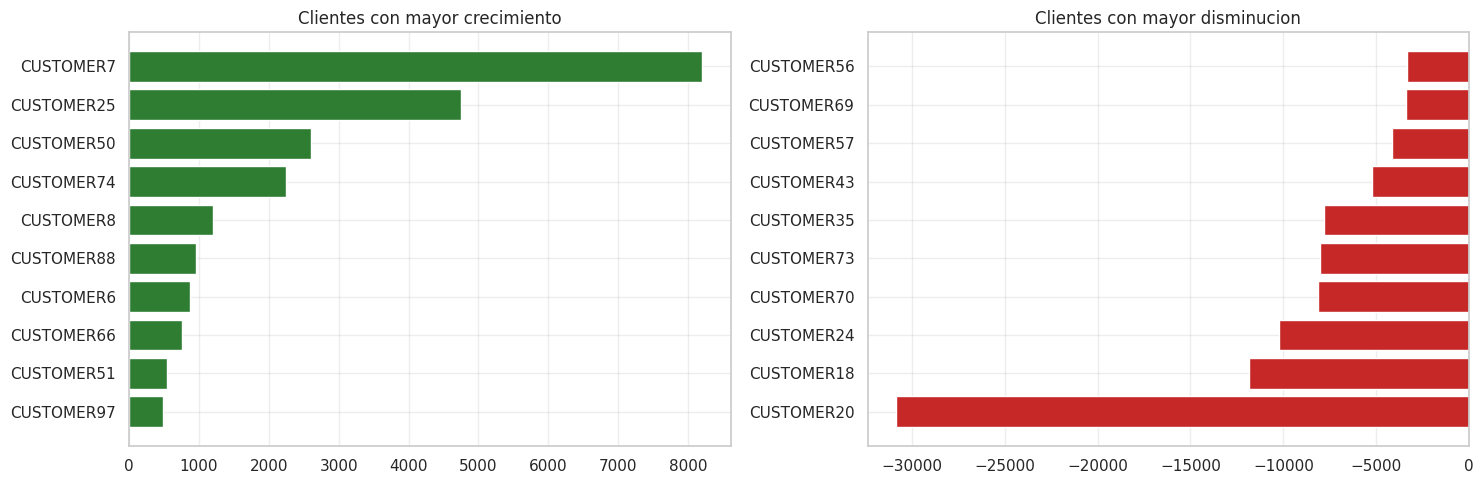

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_15_clientes_crecen_disminuyen.jpg


In [15]:
# Compara clientes recientes para detectar crecimiento o caida.
# Clientes que crecen o disminuyen: comparacion ultimos 3 meses vs 3 meses anteriores.
months_sorted = sorted(monthly['Month_dt'].unique())
last_3 = months_sorted[-3:]
prev_3 = months_sorted[-6:-3]

cliente_prev = (
    monthly[monthly['Month_dt'].isin(prev_3)]
    .groupby('Cliente', observed=True)['Cust_Sales'].sum()
    .reset_index(name='ventas_prev_3m')
)
cliente_last = (
    monthly[monthly['Month_dt'].isin(last_3)]
    .groupby('Cliente', observed=True)['Cust_Sales'].sum()
    .reset_index(name='ventas_last_3m')
)
clientes_trend = cliente_prev.merge(cliente_last, on='Cliente', how='outer').fillna(0)
clientes_trend['cambio_abs'] = clientes_trend['ventas_last_3m'] - clientes_trend['ventas_prev_3m']
clientes_trend['cambio_%'] = clientes_trend['cambio_abs'] / (clientes_trend['ventas_prev_3m'].abs() + 1) * 100
clientes_trend['estado_cliente'] = np.select(
    [
        clientes_trend['cambio_%'] >= 20,
        clientes_trend['cambio_%'] <= -20
    ],
    ['Creciendo', 'Disminuyendo'],
    default='Estable'
)
clientes_trend = clientes_trend.sort_values('cambio_abs', ascending=False)
clientes_trend.to_csv(output_path('eda_clientes_crecen_disminuyen.csv'), index=False)

print('Top clientes creciendo:')
display(clientes_trend.head(10))
print('Top clientes disminuyendo:')
display(clientes_trend.sort_values('cambio_abs').head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
top_grow = clientes_trend.head(10).sort_values('cambio_abs')
top_drop = clientes_trend.sort_values('cambio_abs').head(10).sort_values('cambio_abs')
axes[0].barh(top_grow['Cliente'], top_grow['cambio_abs'], color='#2E7D32')
axes[0].set_title('Clientes con mayor crecimiento')
axes[1].barh(top_drop['Cliente'], top_drop['cambio_abs'], color='#C62828')
axes[1].set_title('Clientes con mayor disminucion')
savefig('eda_15_clientes_crecen_disminuyen.jpg')

Clientes necesarios para explicar ~80% de ventas: 14 de 98
Productos necesarios para explicar ~80% de ventas: 175 de 2093
Top 20% clientes concentra: 90.2% de ventas
Top 20% productos concentra: 96.6% de ventas


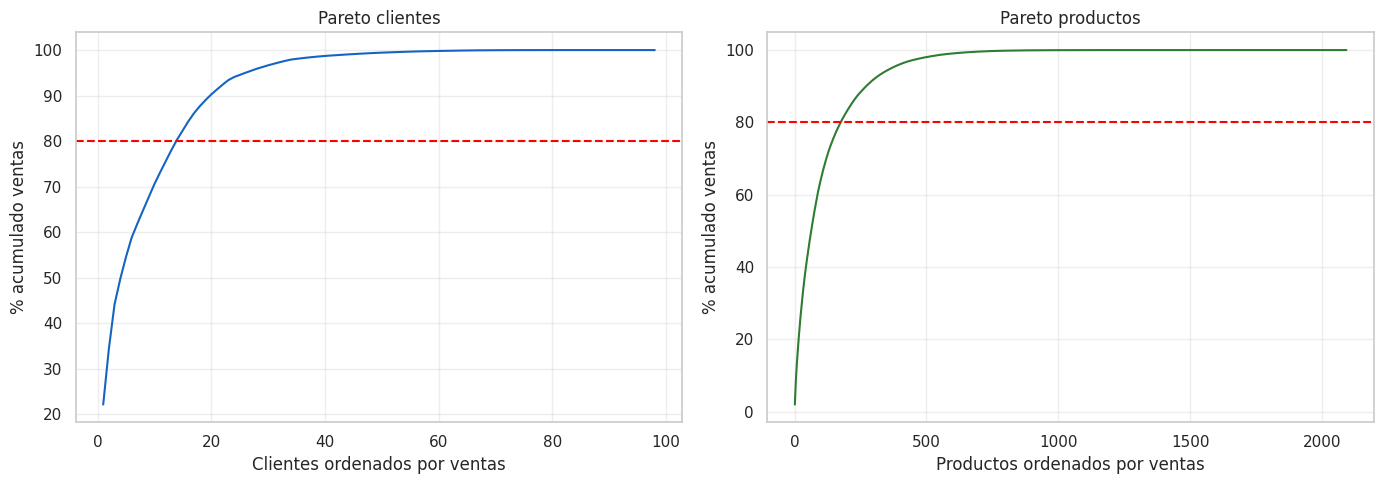

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_16_pareto_clientes_productos.jpg
Interpretacion simple:
El Pareto muestra si el negocio depende de pocos clientes o productos. Si la curva sube muy rapido, hay concentracion y riesgo comercial.


In [16]:
# Calcula Pareto para saber que clientes y productos concentran ventas.
# Participacion de productos y Pareto 80/20 para clientes y productos.
def pareto_table(df, key, value='Cust_Sales'):
    out = (
        df.groupby(key, observed=True)[value]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )
    total = out[value].sum()
    out['participacion_%'] = out[value] / total * 100 if total else 0
    out['participacion_acum_%'] = out['participacion_%'].cumsum()
    out['en_pareto_80'] = out['participacion_acum_%'] <= 80
    if len(out) and not out['en_pareto_80'].any():
        out.loc[0, 'en_pareto_80'] = True
    return out

pareto_clientes = pareto_table(monthly, 'Cliente')
pareto_productos = pareto_table(monthly, 'Producto')
pareto_clientes.to_csv(output_path('pareto_clientes.csv'), index=False)
pareto_productos.to_csv(output_path('pareto_productos.csv'), index=False)

n_clientes_80 = int((pareto_clientes['participacion_acum_%'] <= 80).sum() + 1)
n_productos_80 = int((pareto_productos['participacion_acum_%'] <= 80).sum() + 1)
share_clientes_20 = pareto_clientes.head(max(1, int(np.ceil(len(pareto_clientes) * 0.2))))['participacion_%'].sum()
share_productos_20 = pareto_productos.head(max(1, int(np.ceil(len(pareto_productos) * 0.2))))['participacion_%'].sum()

print(f'Clientes necesarios para explicar ~80% de ventas: {n_clientes_80} de {len(pareto_clientes)}')
print(f'Productos necesarios para explicar ~80% de ventas: {n_productos_80} de {len(pareto_productos)}')
print(f'Top 20% clientes concentra: {share_clientes_20:.1f}% de ventas')
print(f'Top 20% productos concentra: {share_productos_20:.1f}% de ventas')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(np.arange(1, len(pareto_clientes)+1), pareto_clientes['participacion_acum_%'], color='#1565C0')
axes[0].axhline(80, color='red', linestyle='--')
axes[0].set_title('Pareto clientes')
axes[0].set_xlabel('Clientes ordenados por ventas')
axes[0].set_ylabel('% acumulado ventas')

axes[1].plot(np.arange(1, len(pareto_productos)+1), pareto_productos['participacion_acum_%'], color='#2E7D32')
axes[1].axhline(80, color='red', linestyle='--')
axes[1].set_title('Pareto productos')
axes[1].set_xlabel('Productos ordenados por ventas')
axes[1].set_ylabel('% acumulado ventas')
savefig('eda_16_pareto_clientes_productos.jpg')

print('Interpretacion simple:')
print('El Pareto muestra si el negocio depende de pocos clientes o productos. Si la curva sube muy rapido, hay concentracion y riesgo comercial.')

Productos con riesgo historico de desabastecimiento:


,Producto,Product_Type,ventas_total,ventas_prom_mensual,inventario_prom,inventario_ultimo,rotacion_prom,cobertura_prom_sem,stockout_rate,cobertura_ult_sem,clasificacion_inventario
763,"MOBILE,SM-A156M/N,LIGHT BLUE,COM",MOBILE,79530.0,3787.142822,7604.856934,12.0,1.278430,26.386820,0.000000,0.013625,Riesgo desabastecimiento
762,"MOBILE,SM-A156M/N,BLACK,COM",MOBILE,78168.0,3722.285645,7010.761719,12.0,0.789006,44.519096,0.000000,0.013862,Riesgo desabastecimiento
750,"MOBILE,SM-A145M,BLACK,COM",MOBILE,87557.0,2653.242432,3764.151611,1.0,0.699973,7.482155,0.000000,0.001621,Riesgo desabastecimiento
751,"MOBILE,SM-A145M,SILVER,COM",MOBILE,67299.0,2039.363647,2821.090820,1.0,0.934400,16.709578,0.000000,0.002108,Riesgo desabastecimiento
977,"MOBILE,SM-A556E,BLACK,COM",MOBILE,34408.0,1638.476196,2622.619141,13.0,1.033787,34.533546,0.000000,0.034116,Riesgo desabastecimiento
833,"MOBILE,SM-A245M/N,BLACK,COM",MOBILE,68907.0,1531.266724,1705.688843,0.0,1.269179,2.903456,0.066667,0.000000,Riesgo desabastecimiento
902,"MOBILE,SM-A356E,BLACK,COM",MOBILE,60311.0,1435.976196,2468.142822,0.0,0.750429,23.123926,0.023810,0.000000,Riesgo desabastecimiento
899,"MOBILE,SM-A346M/N,BLACK,COM",MOBILE,40588.0,1229.939453,1502.848511,1.0,0.726953,10.476542,0.030303,0.003496,Riesgo desabastecimiento
673,"MOBILE,SM-A042M,BLACK,COM",MOBILE,37506.0,1136.545410,1346.363647,0.0,1.229832,86.139091,0.060606,0.000000,Riesgo desabastecimiento
835,"MOBILE,SM-A245M/N,SILVER,COM",MOBILE,37124.0,1124.969727,771.878784,0.0,2.431500,2.041600,0.060606,0.000000,Riesgo desabastecimiento


Productos con posible exceso de inventario:


,Producto,Product_Type,ventas_total,ventas_prom_mensual,inventario_prom,inventario_ultimo,rotacion_prom,cobertura_prom_sem,stockout_rate,cobertura_ult_sem,clasificacion_inventario
9,"AV RECEIVER,HW-B400F,COLOMBIA",AV RECEIVER,2.0,0.031746,3.698413,98.0,0.000321,3.204586,0.000000,5637.757812,Exceso inventario
11,"AV RECEIVER,HW-B450F,COLOMBIA",AV RECEIVER,0.0,0.000000,4.444445,40.0,0.000000,4.444445,0.000000,4000.000000,Exceso inventario
1581,"OLED SCREEN,QN77S90FAK,77,COLOMBIA,DWE51",OLED SCREEN,2.0,0.095238,2.238095,28.0,0.004023,1.815813,0.000000,870.961182,Exceso inventario
2086,"VCS,SEM,120V/60HZ,410,MULTI CYCLONE",VCS,2.0,0.033333,2.150000,10.0,0.002302,2.065094,0.000000,563.318787,Exceso inventario
2088,"VCS,SEM,120V/60HZ,770,MULTI CYCLONE",VCS,3.0,0.076923,1.923077,15.0,0.006727,1.768263,0.000000,537.844788,Exceso inventario
2085,"VCS,SEM,120V/60HZ,1050,MULTI CYCLONE",VCS,5.0,0.083333,1.266667,15.0,0.009687,1.140665,0.000000,510.554108,Exceso inventario
271,"LED MON,C32F391FWL,32,COLOMBIA,LW61/S32",LED MON,0.0,0.000000,4.696970,5.0,0.000000,4.696970,0.000000,500.000000,Exceso inventario
142,"DVM,1.5,KW,SETIN,HP,R410A",DVM,0.0,0.000000,0.878788,4.0,0.000000,0.878788,0.000000,400.000000,Exceso inventario
89,"BLU-RAY DISC PLAYER,BD-D5300,MEXICO",BLU-RAY DISC PLAYER,0.0,0.000000,2.787879,4.0,0.000000,2.787879,0.000000,400.000000,Exceso inventario
181,"DVM,9.0,KW,SETIN,HP,R410A",DVM,5.0,0.075758,0.878788,9.0,0.048485,0.835498,0.015152,325.873932,Exceso inventario


Productos de alta rotacion:


,Producto,Product_Type,ventas_total,ventas_prom_mensual,inventario_prom,inventario_ultimo,rotacion_prom,cobertura_prom_sem,stockout_rate,cobertura_ult_sem,clasificacion_inventario
705,"MOBILE,SM-A065M/DS,LIGHT GREEN,LTC",MOBILE,46772.0,111.361908,246.866669,89.0,11.627278,30.059856,0.061905,3.435217,Alta rotacion
688,"MOBILE,SM-A055M/DS,BLACK,LTC",MOBILE,169753.0,244.953827,529.852844,286.0,11.587610,31.980156,0.072150,5.019657,Alta rotacion
704,"MOBILE,SM-A065M/DS,LIGHT BLUE,LTC",MOBILE,64209.0,138.980515,316.660187,233.0,10.884085,35.297390,0.054113,7.206695,Alta rotacion
689,"MOBILE,SM-A055M/DS,LIGHT GREEN,LTC",MOBILE,90372.0,142.767776,367.041077,128.0,10.192214,28.854155,0.085308,3.854052,Alta rotacion
703,"MOBILE,SM-A065M/DS,BLACK,LTC",MOBILE,79100.0,156.944443,404.567474,239.0,8.857426,53.078716,0.045635,6.546384,Alta rotacion
380,"LED TV,UN50DU8200K,50,COLOMBIA,UWK40/U50",LED TV,11602.0,120.854164,198.270828,136.0,8.022679,28.157532,0.062500,4.837169,Alta rotacion
2043,"TABLET,SM-X110,SILVER,L13",TABLET,6352.0,24.620155,54.500000,28.0,7.938343,20.851309,0.170543,4.881776,Alta rotacion
1977,"TABLET,SM-P620,GRAY,COO",TABLET,19789.0,60.516819,106.574921,41.0,6.777602,8.108287,0.103976,2.911171,Alta rotacion
1390,"MOBILE,SM-S721B/DS,BLACK,LTC",MOBILE,12992.0,31.381643,53.514492,40.0,6.407209,5.639402,0.060386,5.473412,Alta rotacion
1392,"MOBILE,SM-S721B/DS,LIGHT BLUE,LTC",MOBILE,6743.0,18.887955,35.106441,59.0,5.415290,6.409317,0.070028,13.401331,Alta rotacion


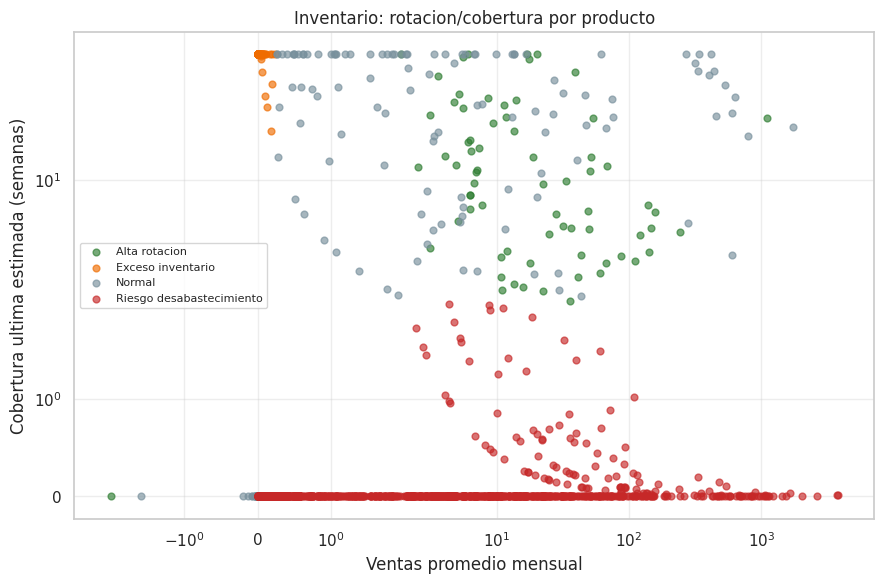

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/eda_17_inventario_rotacion_cobertura.jpg


In [17]:
# Clasifica productos por rotacion, cobertura y riesgo de inventario.
# Inventarios: rotacion, cobertura, exceso y riesgo historico de quiebre por producto.
ult_mes = monthly['Month_dt'].max()
inv_producto = (
    monthly.groupby(['Producto', 'Product_Type'], observed=True)
    .agg(
        ventas_total=('Cust_Sales', 'sum'),
        ventas_prom_mensual=('Cust_Sales', 'mean'),
        inventario_prom=('Channel_Inv', 'mean'),
        inventario_ultimo=('Channel_Inv', lambda s: s.iloc[-1]),
        rotacion_prom=('Inventory_Turnover', 'mean'),
        cobertura_prom_sem=('Stock_coverage_weeks', 'mean'),
        stockout_rate=('stockout_flag', 'mean')
    )
    .reset_index()
)
inv_producto['cobertura_ult_sem'] = inv_producto['inventario_ultimo'].clip(lower=0) / ((inv_producto['ventas_prom_mensual'].clip(lower=0) / 4.3) + 0.01)
inv_producto['clasificacion_inventario'] = np.select(
    [
        (inv_producto['cobertura_ult_sem'] < 2) & (inv_producto['ventas_prom_mensual'] > 0),
        (inv_producto['cobertura_ult_sem'] > 12) & (inv_producto['ventas_prom_mensual'] < inv_producto['ventas_prom_mensual'].median()),
        inv_producto['rotacion_prom'] >= inv_producto['rotacion_prom'].quantile(0.80)
    ],
    ['Riesgo desabastecimiento', 'Exceso inventario', 'Alta rotacion'],
    default='Normal'
)
inv_producto.to_csv(output_path('inventario_rotacion_cobertura_productos.csv'), index=False)

print('Productos con riesgo historico de desabastecimiento:')
display(inv_producto[inv_producto['clasificacion_inventario'] == 'Riesgo desabastecimiento'].sort_values('ventas_prom_mensual', ascending=False).head(10))
print('Productos con posible exceso de inventario:')
display(inv_producto[inv_producto['clasificacion_inventario'] == 'Exceso inventario'].sort_values('cobertura_ult_sem', ascending=False).head(10))
print('Productos de alta rotacion:')
display(inv_producto[inv_producto['clasificacion_inventario'] == 'Alta rotacion'].sort_values('rotacion_prom', ascending=False).head(10))

fig, ax = plt.subplots(figsize=(9, 6))
sample_inv = inv_producto.sample(min(3000, len(inv_producto)), random_state=42)
colors_inv = {
    'Riesgo desabastecimiento': '#C62828',
    'Exceso inventario': '#EF6C00',
    'Alta rotacion': '#2E7D32',
    'Normal': '#78909C'
}
for cls, grp_inv in sample_inv.groupby('clasificacion_inventario'):
    ax.scatter(grp_inv['ventas_prom_mensual'], grp_inv['cobertura_ult_sem'].clip(0, 52),
               label=cls, alpha=0.65, s=24, color=colors_inv.get(cls, '#78909C'))
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_xlabel('Ventas promedio mensual')
ax.set_ylabel('Cobertura ultima estimada (semanas)')
ax.set_title('Inventario: rotacion/cobertura por producto')
ax.legend(fontsize=8)
savefig('eda_17_inventario_rotacion_cobertura.jpg')

<center>
<font face="Cambria" size=5><b>7. Modelo predictivo supervisado</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Predecir demanda futura por cliente y producto usando información histórica disponible hasta cada mes.

**Cuidado metodológico.** El target futuro nunca entra como feature y el test se reserva para el reporte final.

</font>

In [18]:
# Construye variables historicas y el target del siguiente mes.
df_model = monthly.sort_values(['Cliente', 'Producto', 'Month_dt']).copy()
grp = df_model.groupby(['Cliente', 'Producto'], observed=True)

for lag in [1, 2, 3, 4, 6]:
    df_model[f'lag_{lag}'] = grp['Cust_Sales'].shift(lag)

df_model['rolling_3m'] = grp['Cust_Sales'].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
df_model['rolling_6m'] = grp['Cust_Sales'].transform(lambda s: s.shift(1).rolling(6, min_periods=1).mean())
df_model['lag_inv_1'] = grp['Channel_Inv'].shift(1)
df_model['lag_sellin_1'] = grp['Sell_in'].shift(1)
df_model['inv_to_sales_lag'] = (df_model['lag_inv_1'] / (df_model['lag_1'].abs() + 1)).clip(0, 100)
df_model['sellin_to_sales_lag'] = (df_model['lag_sellin_1'] / (df_model['lag_1'].abs() + 1)).clip(0, 100)
df_model['es_q4'] = (df_model['trimestre'] == 4).astype('int8')

client_month = monthly.groupby(['Cliente', 'Month_dt'], observed=True)['Cust_Sales'].sum().reset_index()
client_month['trend_cliente_3m'] = client_month.groupby('Cliente', observed=True)['Cust_Sales'].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
df_model = df_model.merge(client_month[['Cliente', 'Month_dt', 'trend_cliente_3m']], on=['Cliente', 'Month_dt'], how='left')

le_cliente = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
le_producto = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
le_tipo = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_model['Cliente_enc'] = le_cliente.fit_transform(df_model[['Cliente']].astype(str)).astype('float32')
df_model['Producto_enc'] = le_producto.fit_transform(df_model[['Producto']].astype(str)).astype('float32')
df_model['ProductType_enc'] = le_tipo.fit_transform(df_model[['Product_Type']].astype(str)).astype('float32')

# Target: demanda neta del mes siguiente para la misma combinacion cliente-producto.
df_model['target_next_month'] = grp['Cust_Sales'].shift(-1)

FEATURES = [
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_6',
    'rolling_3m', 'rolling_6m',
    'lag_inv_1', 'lag_sellin_1', 'inv_to_sales_lag', 'sellin_to_sales_lag',
    'Inventory_Turnover', 'Sell_through_rate', 'Stock_coverage_weeks', 'channel_inv_negative_flag',
    'mes', 'trimestre', 'es_q4', 'trend_cliente_3m',
    'Cliente_enc', 'Producto_enc', 'ProductType_enc'
]

df_clean = df_model.dropna(subset=['target_next_month']).copy()
print('Dataset de modelado:', df_clean.shape)
print('Rango fechas features:', df_clean['Month_dt'].min().date(), '->', df_clean['Month_dt'].max().date())
print('Target ceros:', f"{(df_clean['target_next_month'] == 0).mean()*100:.1f}%")
display(df_clean[['Cliente','Producto','Month_dt','Cust_Sales','target_next_month'] + FEATURES[:5]].head())

Dataset de modelado: (316380, 35)
Rango fechas features: 2023-01-01 -> 2025-07-01
Target ceros: 65.5%


,Cliente,Producto,Month_dt,Cust_Sales,target_next_month,lag_1,lag_2,lag_3,lag_4,lag_6
0,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",2023-01-01,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",2023-02-01,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",2023-03-01,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",2023-04-01,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,CUSTOMER1,"MOBILE,SM-A032M/DS,BLACK,LTC",2023-05-01,0.0,0.0,0.0,0.0,0.0,0.0,NaN


<center>
<font face="Cambria" size=5><b>7.1 Comparación multi-modelo: RF, Árbol, GBM y XGBoost</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Comparar candidatos con la misma partición temporal y elegir el campeón usando solo validation.

**Modelos.** Random Forest, Árbol de Decisión, GBM HistGradientBoosting y XGBoost.

**Nota.** Las devoluciones se conservan como señal histórica, pero la demanda futura se modela como no negativa.

</font>

Meses validation: ['2024-11', '2024-12', '2025-01']
Meses test final reservado: ['2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07']
Train: (242675, 22) | Validation: (31243, 22) | Test reservado: (42462, 22)
Entrenando Random Forest...
Entrenando Arbol de Decision...
Entrenando GBM HistGradientBoosting...
Entrenando XGBoost...

Ranking de seleccion en validation:


,modelo_base,MAE,RMSE,WAPE_%,R2
0,XGBoost,22.983451,155.486645,75.062428,0.510027
1,Random Forest,23.715252,165.574942,77.452442,0.444383
2,Arbol de Decision,23.989531,163.780413,78.348218,0.456362
3,GBM HistGradientBoosting,26.924106,197.146860,87.932347,0.212291
4,Baseline cero,30.619115,224.230237,100.000000,-0.019001
5,Baseline rolling_3m,31.495748,186.837929,102.863028,0.292517
6,Baseline lag_1,35.036232,220.457114,114.426013,0.015004


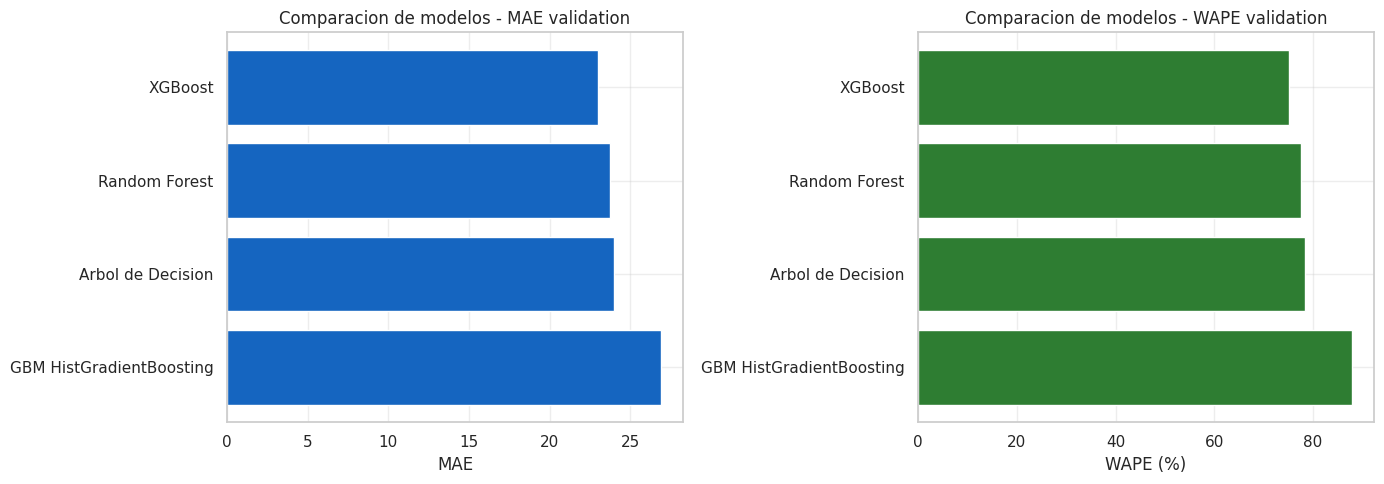

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/modelo_comparacion_multimodelo.jpg
GANADOR DE LA COMPARACION POR VALIDATION: XGBoost
Test reservado: no se usa para seleccionar modelo.


7

In [19]:
# Compara modelos usando validation y deja test reservado.
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Calcula errores del modelo en unidades y porcentajes.
def regression_metrics(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    denom = np.sum(np.abs(y_true))
    wape = np.nan if denom == 0 else np.sum(np.abs(y_true - y_pred)) / denom * 100
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)) * 100
    r2 = r2_score(y_true, y_pred)
    return {'modelo': label, 'MAE': mae, 'RMSE': rmse, 'WAPE_%': wape, 'sMAPE_%': smape, 'R2': r2}

# Usa cero cuando una regla simple no tiene historial disponible.
def baseline_or_zero(values):
    return pd.Series(values).fillna(0).to_numpy(dtype='float32')

# Separa los meses en train, validation y test respetando el orden del tiempo.
def temporal_split_masks(df, date_col='Month_dt', test_months=None, val_months=None):
    unique_months = np.array(sorted(df[date_col].unique()))
    test_n = min(6, max(1, len(unique_months) // 5)) if test_months is None else test_months
    remaining = max(1, len(unique_months) - test_n)
    val_n = min(3, max(1, remaining // 5)) if val_months is None else val_months
    val_periods = unique_months[-(test_n + val_n):-test_n]
    test_periods = unique_months[-test_n:]
    train_mask = df[date_col] < val_periods[0]
    val_mask = df[date_col].isin(val_periods)
    test_mask = df[date_col].isin(test_periods)
    return train_mask, val_mask, test_mask, val_periods, test_periods

# Crea el modelo solicitado con parametros fijos para comparar justamente.
def make_candidate_model(nombre):
    if nombre == 'Random Forest':
        return RandomForestRegressor(
            n_estimators=90,
            max_depth=18,
            min_samples_leaf=12,
            max_features='sqrt',
            bootstrap=True,
            max_samples=0.70,
            n_jobs=-1,
            random_state=42
        )
    if nombre == 'Arbol de Decision':
        return DecisionTreeRegressor(
            max_depth=14,
            min_samples_leaf=25,
            random_state=42
        )
    if nombre == 'GBM HistGradientBoosting':
        return HistGradientBoostingRegressor(
            max_iter=260,
            learning_rate=0.055,
            max_leaf_nodes=31,
            min_samples_leaf=30,
            l2_regularization=0.10,
            random_state=42
        )
    if nombre == 'XGBoost':
        return XGBRegressor(
            n_estimators=350,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=5,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=1.5,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1,
            tree_method='hist'
        )
    raise ValueError(f'Modelo no soportado: {nombre}')

# Entrena un candidato y devuelve sus predicciones en los cortes disponibles.
def fit_predict_candidate(nombre, X_train, y_train, X_val=None, y_val=None, X_test=None):
    model_candidate = make_candidate_model(nombre)
    y_train_log = np.log1p(pd.Series(y_train).clip(lower=0).to_numpy(dtype='float32'))
    if not np.isfinite(y_train_log).all():
        raise ValueError(f'y_train_log contiene valores no finitos para {nombre}.')

    fill_values = None
    X_train_model = X_train
    X_val_model = X_val
    X_test_model = X_test
    if nombre in ['Random Forest', 'Arbol de Decision']:
        fill_values = X_train.median(numeric_only=True).replace([np.inf, -np.inf], np.nan).fillna(0)
        X_train_model = X_train.fillna(fill_values)
        X_val_model = X_val.fillna(fill_values) if X_val is not None else None
        X_test_model = X_test.fillna(fill_values) if X_test is not None else None

    if nombre == 'XGBoost' and X_val_model is not None and y_val is not None:
        y_val_log = np.log1p(pd.Series(y_val).clip(lower=0).to_numpy(dtype='float32'))
        model_candidate.fit(X_train_model, y_train_log, eval_set=[(X_val_model, y_val_log)], verbose=False)
    else:
        model_candidate.fit(X_train_model, y_train_log)

    result = {'model': model_candidate, 'fill_values': fill_values}
    result['pred_train'] = np.expm1(model_candidate.predict(X_train_model)).clip(min=0)
    if X_val_model is not None:
        result['pred_val'] = np.expm1(model_candidate.predict(X_val_model)).clip(min=0)
    if X_test_model is not None:
        result['pred_test'] = np.expm1(model_candidate.predict(X_test_model)).clip(min=0)
    return result


MODEL_CANDIDATES = ['Random Forest', 'Arbol de Decision', 'GBM HistGradientBoosting', 'XGBoost']

df_clean = df_clean.copy()
df_clean['target_demand_base'] = df_clean['target_next_month'].clip(lower=0)
df_clean_base = df_clean.dropna(subset=['target_demand_base']).copy()
train_mask, val_mask, test_mask, val_months, test_months = temporal_split_masks(df_clean_base)

X_train = df_clean_base.loc[train_mask, FEATURES]
y_train = df_clean_base.loc[train_mask, 'target_demand_base']
X_val = df_clean_base.loc[val_mask, FEATURES]
y_val = df_clean_base.loc[val_mask, 'target_demand_base']
X_test = df_clean_base.loc[test_mask, FEATURES]
y_test = df_clean_base.loc[test_mask, 'target_demand_base']

assert y_train.notna().all() and y_val.notna().all() and y_test.notna().all(), 'El target contiene NaN despues de la limpieza.'

print('Meses validation:', pd.to_datetime(val_months).strftime('%Y-%m').tolist())
print('Meses test final reservado:', pd.to_datetime(test_months).strftime('%Y-%m').tolist())
print('Train:', X_train.shape, '| Validation:', X_val.shape, '| Test reservado:', X_test.shape)

modelos_entrenados = {}
comparacion_rows = []
for nombre in MODEL_CANDIDATES:
    print(f'Entrenando {nombre}...')
    info = fit_predict_candidate(nombre, X_train, y_train, X_val, y_val, X_test)
    info.update({'target_transform': 'log1p', 'familia': 'Tree/Ensemble' if nombre != 'XGBoost' else 'Boosting'})
    modelos_entrenados[nombre] = info

    row_train = regression_metrics(y_train, info['pred_train'], f'{nombre} train')
    row_train['modelo_base'] = nombre
    row_train['split'] = 'train'
    row_val = regression_metrics(y_val, info['pred_val'], f'{nombre} validation')
    row_val['modelo_base'] = nombre
    row_val['split'] = 'validation'
    comparacion_rows.extend([row_train, row_val])

comparacion_rows.extend([
    dict(regression_metrics(y_val, baseline_or_zero(X_val['lag_1']), 'Baseline lag_1 validation'), modelo_base='Baseline lag_1', split='validation'),
    dict(regression_metrics(y_val, baseline_or_zero(X_val['rolling_3m']), 'Baseline rolling_3m validation'), modelo_base='Baseline rolling_3m', split='validation'),
    dict(regression_metrics(y_val, np.zeros(len(y_val)), 'Baseline cero validation'), modelo_base='Baseline cero', split='validation')
])

comparacion_modelos = pd.DataFrame(comparacion_rows)
comparacion_validation = (
    comparacion_modelos[comparacion_modelos['split'] == 'validation']
    .sort_values(['WAPE_%', 'MAE'])
    .reset_index(drop=True)
)
modelo_ganador_nombre = comparacion_validation.loc[
    ~comparacion_validation['modelo_base'].str.startswith('Baseline'), 'modelo_base'
].iloc[0]
modelo_ganador_info = modelos_entrenados[modelo_ganador_nombre]

print('\nRanking de seleccion en validation:')
display(comparacion_validation[['modelo_base','MAE','RMSE','WAPE_%','R2']])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_cmp = comparacion_validation[~comparacion_validation['modelo_base'].str.startswith('Baseline')].copy()
axes[0].barh(plot_cmp['modelo_base'][::-1], plot_cmp['MAE'][::-1], color='#1565C0')
axes[0].set_title('Comparacion de modelos - MAE validation')
axes[0].set_xlabel('MAE')
axes[1].barh(plot_cmp['modelo_base'][::-1], plot_cmp['WAPE_%'][::-1], color='#2E7D32')
axes[1].set_title('Comparacion de modelos - WAPE validation')
axes[1].set_xlabel('WAPE (%)')
savefig('modelo_comparacion_multimodelo.jpg')

print('=' * 80)
print('GANADOR DE LA COMPARACION POR VALIDATION:', modelo_ganador_nombre)
print('Test reservado: no se usa para seleccionar modelo.')
print('=' * 80)
Path(output_path('modelo_ganador.txt')).write_text(str(modelo_ganador_nombre), encoding='utf-8')


<center>
<font face="Cambria" size=5><b>7.2 Auditoría estadística y backtesting rolling-origin del ganador</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Revisar que el modelo campeón sea estable y que no aprenda información del futuro.

**Prueba principal.** Backtesting rolling-origin con 6 folds, siempre entrenando con pasado y evaluando meses posteriores.

</font>

In [20]:
# Agrega controles anti-fuga y variables historicas.
# Auditoria anti-leakage y nuevas variables historicas sin mirar el futuro.
assert 'target_next_month' not in FEATURES, 'Fuga: el target esta dentro de FEATURES.'
assert all(col in df_clean.columns for col in FEATURES), 'Hay features no construidas.'
assert df_clean['Month_dt'].max() < monthly['Month_dt'].max(), (
    'El target_next_month solo existe hasta el penultimo mes; esto es esperado para entrenamiento.'
)

df_model = df_model.sort_values(['Cliente', 'Producto', 'Month_dt']).copy()
grp = df_model.groupby(['Cliente', 'Producto'], observed=True)

df_model['series_age_months'] = grp.cumcount().astype('int16') + 1
df_model['active_months_hist'] = grp['Cust_Sales'].transform(lambda s: (s.shift(1).fillna(0) > 0).cumsum()).astype('float32')
df_model['avg_sales_hist'] = grp['Cust_Sales'].transform(lambda s: s.shift(1).expanding(min_periods=1).mean()).astype('float32')
df_model['std_sales_hist'] = grp['Cust_Sales'].transform(lambda s: s.shift(1).expanding(min_periods=2).std()).fillna(0).astype('float32')
df_model['zero_rate_hist'] = grp['Cust_Sales'].transform(lambda s: (s.shift(1).fillna(0) == 0).expanding(min_periods=1).mean()).astype('float32')

# Cuenta cuantos meses han pasado desde la última venta positiva.
def months_since_nonzero(values):
    out = []
    gap = 999
    for v in values.shift(1).fillna(0):
        if v > 0:
            gap = 0
        else:
            gap += 1
        out.append(gap)
    return pd.Series(out, index=values.index, dtype='float32')

df_model['months_since_nonzero'] = grp['Cust_Sales'].transform(months_since_nonzero).clip(0, 36).astype('float32')
df_model['target_demand'] = df_model['target_next_month'].clip(lower=0)

ADVANCED_FEATURES = FEATURES + [
    'series_age_months', 'active_months_hist', 'avg_sales_hist',
    'std_sales_hist', 'zero_rate_hist', 'months_since_nonzero']

df_clean_adv = df_model.dropna(subset=['target_demand', 'target_next_month']).copy()

leakage_audit = pd.DataFrame([
    {'control': 'Target no incluido en features', 'resultado': 'OK', 'detalle': 'target_next_month no esta en FEATURES'},
    {'control': 'Lags y rolling usan shift(1)', 'resultado': 'OK', 'detalle': 'Las ventas del mes objetivo no entran al entrenamiento'},
    {'control': 'Split temporal', 'resultado': 'OK', 'detalle': 'Train siempre antecede a test en el backtesting'},
    {'control': 'Demanda no negativa', 'resultado': 'OK', 'detalle': 'target_demand conserva devoluciones en auditoria, pero predice demanda >= 0'},
    {'control': 'Ceros futuros', 'resultado': 'OK', 'detalle': 'Semanas no observadas se marcan y excluyen del modelado'}])
display(leakage_audit)


print('Dataset avanzado:', df_clean_adv.shape)
print('Features avanzadas:', len(ADVANCED_FEATURES))
print('Rango trainable:', df_clean_adv['Month_dt'].min().date(), '->', df_clean_adv['Month_dt'].max().date())

,control,resultado,detalle
0,Target no incluido en features,OK,target_next_month no esta en FEATURES
1,Lags y rolling usan shift(1),OK,Las ventas del mes objetivo no entran al entre...
2,Split temporal,OK,Train siempre antecede a test en el backtesting
3,Demanda no negativa,OK,target_demand conserva devoluciones en auditor...
4,Ceros futuros,OK,Semanas no observadas se marcan y excluyen del...


Dataset avanzado: (316380, 42)
Features avanzadas: 28
Rango trainable: 2023-01-01 -> 2025-07-01


In [21]:
# Segmenta las series para revisar resultados por tipo de demanda
# Util para auditar donde acierta/falla el modelo.
series_profile = (
    monthly.groupby(['Cliente', 'Producto'], observed=True)
    .agg(
        total_sales=('Cust_Sales', 'sum'),
        avg_sales=('Cust_Sales', 'mean'),
        positive_months=('Cust_Sales', lambda s: int((s > 0).sum())),
        months=('Cust_Sales', 'size'),
        last_month=('Month_dt', 'max')
    )
    .reset_index()
)
series_profile['zero_rate'] = 1 - series_profile['positive_months'] / series_profile['months']
positive_totals = series_profile.loc[series_profile['total_sales'] > 0, 'total_sales']
q80 = positive_totals.quantile(0.80) if len(positive_totals) else 0
q50 = positive_totals.quantile(0.50) if len(positive_totals) else 0
series_profile['volume_segment'] = np.select(
    [
        series_profile['total_sales'] >= q80,
        series_profile['total_sales'] >= q50,
        series_profile['total_sales'] > 0
    ],
    ['A_alta_rotacion', 'B_media_rotacion', 'C_baja_rotacion'],
    default='D_sin_demanda'
)
series_profile['intermittency_segment'] = np.select(
    [
        series_profile['zero_rate'] >= 0.80,
        series_profile['zero_rate'] >= 0.50
    ],
    ['intermitente_alta', 'intermitente_media'],
    default='demanda_recurrente'
)
series_profile.to_csv(output_path('perfil_series_demanda.csv'), index=False)

print('Segmentos por volumen:')
display(series_profile['volume_segment'].value_counts().to_frame('series'))
print('Segmentos por intermitencia:')
display(series_profile['intermittency_segment'].value_counts().to_frame('series'))


Segmentos por volumen:


,series
volume_segment,
C_baja_rotacion,6029
D_sin_demanda,4930
B_media_rotacion,3626
A_alta_rotacion,2416


Segmentos por intermitencia:


,series
intermittency_segment,
intermitente_alta,8598
intermitente_media,4378
demanda_recurrente,4025


,modelo,folds,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,XGBoost log1p demanda,6,21.672847,141.460810,63.971505,134.222000,0.482130
1,Baseline cero,6,36.819180,217.158077,100.000000,86.515002,-0.029077
2,Baseline rolling_3m,6,35.434388,189.259701,102.736317,90.430137,0.115033
3,Baseline lag_1,6,34.647850,193.954702,102.736501,72.205751,-0.008909


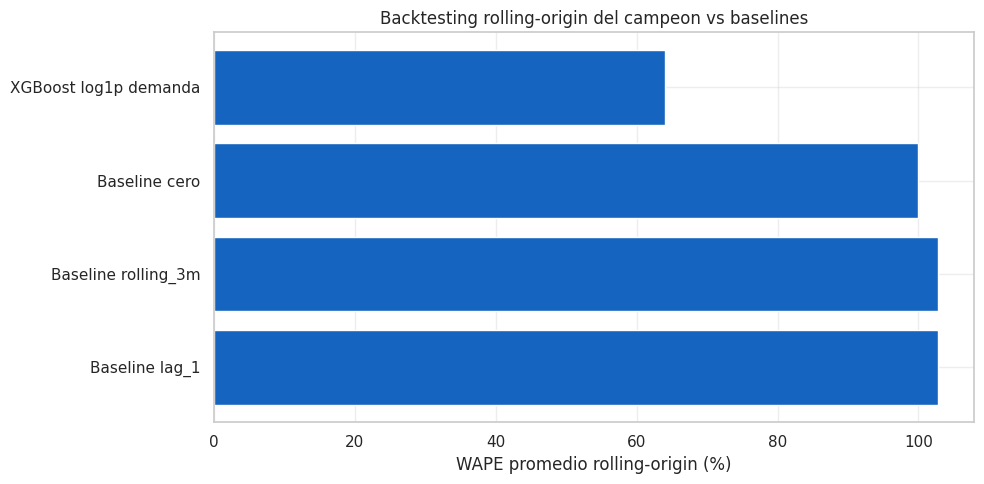

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/modelo_backtesting_wape.jpg


In [22]:
# Evalua el campeón con varios cortes temporales hacia atras.
# Backtesting rolling-origin: varios cortes temporales, entrenando solo con pasado.
# Guarda las metricas de cada fold del backtesting.
def metrics_dict(y_true, y_pred, label, fold):
    row = regression_metrics(y_true, np.clip(y_pred, 0, None), label)
    row['fold'] = fold
    row['n'] = len(y_true)
    row['target_sum'] = float(np.sum(np.abs(y_true)))
    return row

months_adv = np.array(sorted(df_clean_adv['Month_dt'].unique()))
fold_months = months_adv[-6:]
backtest_rows = []

for fold_month in fold_months:
    train_fold = df_clean_adv['Month_dt'] < fold_month
    test_fold = df_clean_adv['Month_dt'] == fold_month
    if train_fold.sum() < 1000 or test_fold.sum() == 0:
        continue

    Xtr = df_clean_adv.loc[train_fold, ADVANCED_FEATURES]
    ytr = df_clean_adv.loc[train_fold, 'target_demand']
    Xte = df_clean_adv.loc[test_fold, ADVANCED_FEATURES]
    yte = df_clean_adv.loc[test_fold, 'target_demand']
    fold_label = pd.Timestamp(fold_month).strftime('%Y-%m')

    backtest_rows.append(metrics_dict(yte, baseline_or_zero(Xte['lag_1']), 'Baseline lag_1', fold_label))
    backtest_rows.append(metrics_dict(yte, baseline_or_zero(Xte['rolling_3m']), 'Baseline rolling_3m', fold_label))
    backtest_rows.append(metrics_dict(yte, np.zeros(len(yte)), 'Baseline cero', fold_label))

    champion_fold = fit_predict_candidate(modelo_ganador_nombre, Xtr, ytr, X_test=Xte)
    backtest_rows.append(metrics_dict(yte, champion_fold['pred_test'], f'{modelo_ganador_nombre} log1p demanda', fold_label))

backtest_results = pd.DataFrame(backtest_rows)
backtest_summary = (
    backtest_results.groupby('modelo')
    .agg(
        folds=('fold', 'nunique'),
        MAE=('MAE', 'mean'),
        RMSE=('RMSE', 'mean'),
        WAPE_pct=('WAPE_%', 'mean'),
        sMAPE_pct=('sMAPE_%', 'mean'),
        R2=('R2', 'mean')
    )
    .sort_values(['WAPE_pct', 'MAE'])
    .reset_index()
)

display(backtest_summary)
backtest_results.to_csv(output_path('backtesting_rolling_origin_detalle.csv'), index=False)

fig, ax = plt.subplots(figsize=(10, 5))
plot_bt = backtest_summary.sort_values('WAPE_pct')
ax.barh(plot_bt['modelo'][::-1], plot_bt['WAPE_pct'][::-1], color='#1565C0')
ax.set_xlabel('WAPE promedio rolling-origin (%)')
ax.set_title('Backtesting rolling-origin del campeon vs baselines')
savefig('modelo_backtesting_wape.jpg')


<center>
<font face="Cambria" size=5><b>7.3 Entrenamiento final y validación del campeón</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Entrenar el modelo campeón con todos los datos disponibles hasta el corte de validación, evaluar una única vez en el test reservado y revisar la importancia de variables y el ajuste visual de las predicciones.

**Etapas.** Entrenamiento final · Importancia de variables · Validación visual real vs. predicho.

</font>

Modelo campeon seleccionado en validation: XGBoost
Meses validation: ['2024-11', '2024-12', '2025-01']
Meses test final: ['2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07']
Train: (242675, 28) Validation: (31243, 28) Test final: (42462, 28)


,modelo,MAE,RMSE,WAPE_%,sMAPE_%,R2
0,XGBoost champion train,12.045170,112.695448,47.015718,151.883254,0.712293
1,XGBoost champion validation,23.555344,161.258661,76.930194,148.161885,0.472974
2,XGBoost champion test,21.366596,139.330682,58.031156,130.352687,0.590125
3,Baseline lag_1,34.673732,194.971536,94.173016,72.794513,0.197399
4,Baseline rolling_3m,35.439679,190.160269,96.253311,91.334475,0.236521
5,Baseline cero,36.819180,220.723860,100.000000,86.515002,-0.028622


,segmento_tipo,segmento,n,ventas_reales,MAE,WAPE_%,R2
4,intermittency_segment,demanda_recurrente,16980,914239.0,29.380339,54.567586,0.539003
6,intermittency_segment,intermitente_media,11988,572499.0,28.789942,60.285489,0.647099
5,intermittency_segment,intermitente_alta,13494,76678.0,4.687743,82.496166,0.347328
0,volume_segment,A_alta_rotacion,11088,1395146.0,71.166177,56.559713,0.565241
1,volume_segment,B_media_rotacion,13326,149638.0,7.362875,65.570022,0.362358
2,volume_segment,C_baja_rotacion,14094,18630.0,1.335305,101.018757,-0.726171
3,volume_segment,D_sin_demanda,3954,2.0,0.313695,62017.490974,-36147.605464


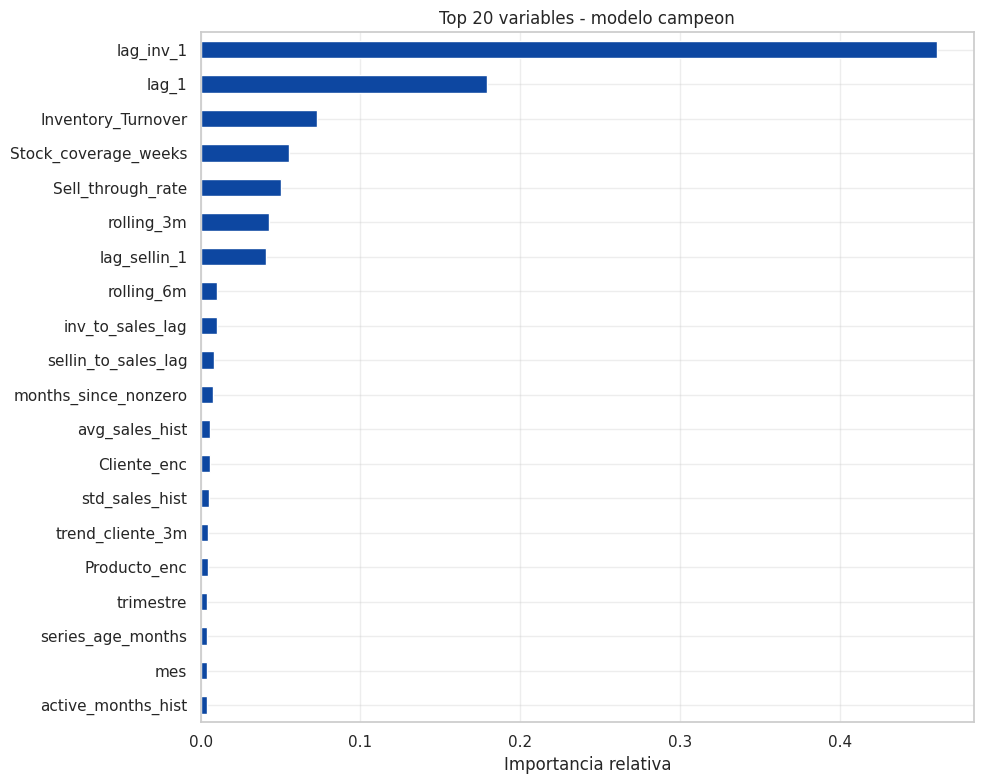

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/modelo_campeon_importancia_variables.jpg


7

In [23]:
# Entrenamiento final del campeón y evaluacion unica en test reservado.
unique_months_adv = np.array(sorted(df_clean_adv['Month_dt'].unique()))
train_mask_adv, val_mask_adv, test_mask_adv, val_months_adv, test_months_adv = temporal_split_masks(df_clean_adv)

X_train_adv = df_clean_adv.loc[train_mask_adv, ADVANCED_FEATURES]
y_train_adv = df_clean_adv.loc[train_mask_adv, 'target_demand']
X_val_adv = df_clean_adv.loc[val_mask_adv, ADVANCED_FEATURES]
y_val_adv = df_clean_adv.loc[val_mask_adv, 'target_demand']
X_test_adv = df_clean_adv.loc[test_mask_adv, ADVANCED_FEATURES]
y_test_adv = df_clean_adv.loc[test_mask_adv, 'target_demand']

print('Modelo campeon seleccionado en validation:', modelo_ganador_nombre)
print('Meses validation:', pd.to_datetime(val_months_adv).strftime('%Y-%m').tolist())
print('Meses test final:', pd.to_datetime(test_months_adv).strftime('%Y-%m').tolist())
print('Train:', X_train_adv.shape, 'Validation:', X_val_adv.shape, 'Test final:', X_test_adv.shape)

final_info = fit_predict_candidate(
    modelo_ganador_nombre,
    X_train_adv,
    y_train_adv,
    X_val=X_val_adv,
    y_val=y_val_adv,
    X_test=X_test_adv
)
model = final_info['model']
pred_train = final_info['pred_train']
pred_val = final_info['pred_val']
pred_test = final_info['pred_test']
TARGET_TRANSFORM = 'log1p'
MODEL_FILL_VALUES = None
FEATURES = ADVANCED_FEATURES
df_clean = df_clean_adv
X_train, X_val, X_test = X_train_adv, X_val_adv, X_test_adv
y_train, y_val, y_test = y_train_adv, y_val_adv, y_test_adv

metrics = pd.DataFrame([
    regression_metrics(y_train, pred_train, f'{modelo_ganador_nombre} champion train'),
    regression_metrics(y_val, pred_val, f'{modelo_ganador_nombre} champion validation'),
    regression_metrics(y_test, pred_test, f'{modelo_ganador_nombre} champion test'),
    regression_metrics(y_test, baseline_or_zero(X_test['lag_1']), 'Baseline lag_1'),
    regression_metrics(y_test, baseline_or_zero(X_test['rolling_3m']), 'Baseline rolling_3m'),
    regression_metrics(y_test, np.zeros(len(y_test)), 'Baseline cero')
])
display(metrics)

comparacion_test = metrics[metrics['modelo'].str.contains('test|Baseline', case=False, na=False)].copy()
comparacion_test['modelo_base'] = comparacion_test['modelo'].str.replace(' champion test', '', regex=False)
comparacion_test['split'] = 'test'

df_test_results = df_clean.loc[test_mask_adv, ['Cliente','Producto','Product_Type','Month_dt','target_demand','target_next_month']].copy()
df_test_results['pred'] = pred_test
df_test_results['error'] = df_test_results['target_demand'] - df_test_results['pred']
df_test_results = df_test_results.merge(
    series_profile[['Cliente','Producto','volume_segment','intermittency_segment']],
    on=['Cliente','Producto'],
    how='left'
)
df_test_results.to_csv(output_path('validacion_predicciones_test.csv'), index=False)

segment_metrics = []
for segment_col in ['volume_segment', 'intermittency_segment']:
    for segment_value, grp_seg in df_test_results.groupby(segment_col, observed=True):
        if len(grp_seg) == 0:
            continue
        row = regression_metrics(grp_seg['target_demand'], grp_seg['pred'], f'{segment_col}:{segment_value}')
        row['segmento_tipo'] = segment_col
        row['segmento'] = segment_value
        row['n'] = len(grp_seg)
        row['ventas_reales'] = grp_seg['target_demand'].sum()
        segment_metrics.append(row)
segment_metrics = pd.DataFrame(segment_metrics)
display(segment_metrics[['segmento_tipo','segmento','n','ventas_reales','MAE','WAPE_%','R2']].sort_values(['segmento_tipo','WAPE_%']))

if hasattr(model, 'feature_importances_'):
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
elif hasattr(model, 'coef_'):
    importances = pd.Series(np.abs(model.coef_), index=FEATURES).sort_values(ascending=False)
else:
    importances = pd.Series(dtype='float64')

if len(importances):
    fig, ax = plt.subplots(figsize=(10, 8))
    importances.head(20).sort_values().plot(kind='barh', ax=ax, color='#0D47A1')
    ax.set_title('Top 20 variables - modelo campeon')
    ax.set_xlabel('Importancia relativa')
    savefig('modelo_campeon_importancia_variables.jpg')

Path(output_path('modelo_ganador.txt')).write_text(str(modelo_ganador_nombre), encoding='utf-8')


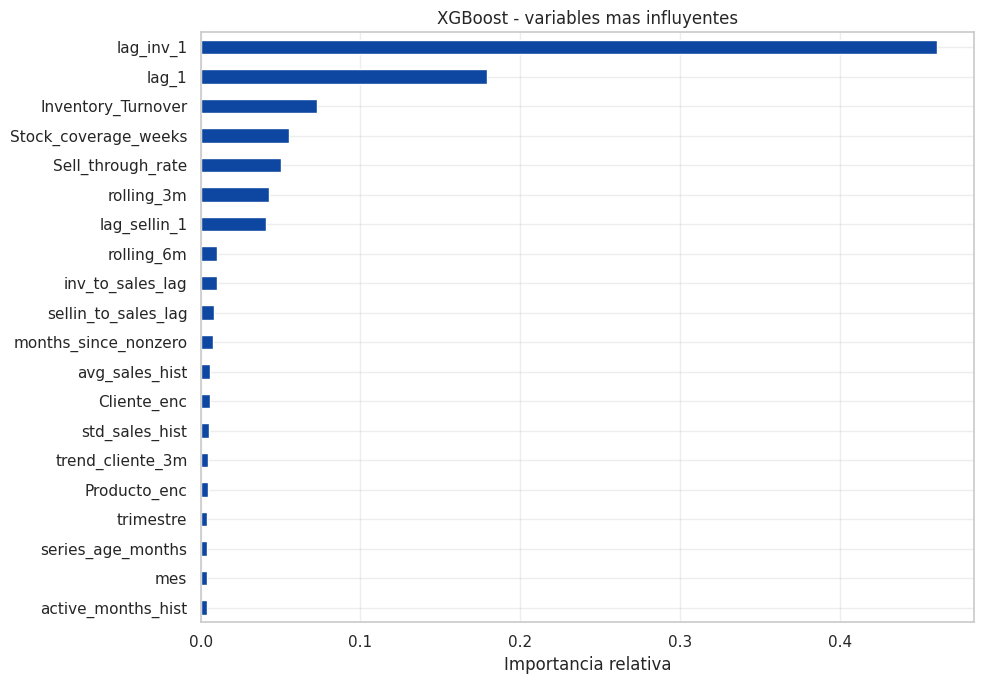

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/modelo_19_xgboost_importancia_variables.jpg
Interpretacion de importancia de variables - XGBoost:
Las variables superiores son las que mas ayudan a reducir el error del modelo.
- lag_inv_1: importancia 0.4609
- lag_1: importancia 0.1793
- Inventory_Turnover: importancia 0.0726
- Stock_coverage_weeks: importancia 0.0552
- Sell_through_rate: importancia 0.0502
- rolling_3m: importancia 0.0428
- lag_sellin_1: importancia 0.0410
- rolling_6m: importancia 0.0104


In [24]:
# Importancia de variables del modelo campeón.
if len(importances):

    fig, ax = plt.subplots(figsize=(10, 7))
    importances.head(20).sort_values().plot(kind='barh', ax=ax, color='#0D47A1')
    ax.set_title(f'{modelo_ganador_nombre} - variables mas influyentes')
    ax.set_xlabel('Importancia relativa')
    savefig('modelo_19_xgboost_importancia_variables.jpg')

    top_features = importances.head(8)
    print(f'Interpretacion de importancia de variables - {modelo_ganador_nombre}:')
    print('Las variables superiores son las que mas ayudan a reducir el error del modelo.')
    for feat, val in top_features.items():
        print(f'- {feat}: importancia {val:.4f}')

    interpretacion_importancia = pd.DataFrame({
        'variable': top_features.index,
        'importancia': top_features.values,
        'lectura_negocio': [
            'Senal historica reciente o estructural que ayuda a anticipar demanda.' for _ in range(len(top_features))
        ]
    })
else:
    interpretacion_importancia = pd.DataFrame(columns=['variable', 'importancia', 'lectura_negocio'])
    print('El modelo campeon no expone importancia de variables nativa.')

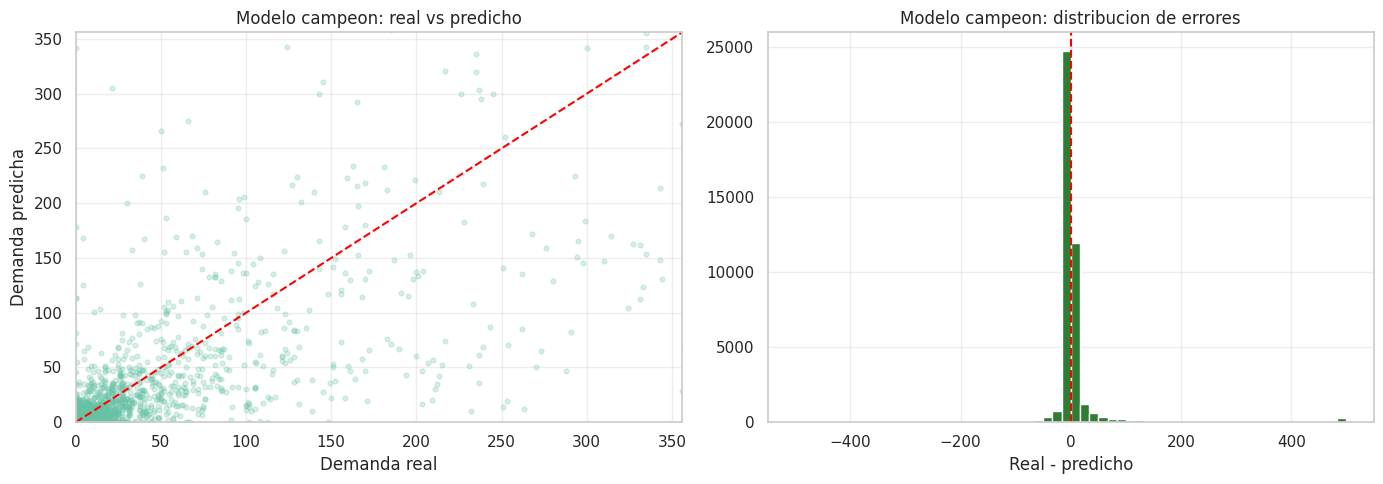

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/modelo_campeon_validacion.jpg
Transformacion objetivo del campeon: log1p


In [25]:
# Grafica que tan cerca quedan las predicciones frente a la demanda real.
# Validacion visual del modelo campeon.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df_test_results.sample(min(5000, len(df_test_results)), random_state=42)
lim = max(1, sample[['target_demand', 'pred']].quantile(0.98).max())
axes[0].scatter(sample['target_demand'], sample['pred'], alpha=0.25, s=12)
axes[0].plot([0, lim], [0, lim], 'r--')
axes[0].set_xlim(0, lim)
axes[0].set_ylim(0, lim)
axes[0].set_title('Modelo campeon: real vs predicho')
axes[0].set_xlabel('Demanda real')
axes[0].set_ylabel('Demanda predicha')

axes[1].hist(df_test_results['error'].clip(-500, 500), bins=60, color='#2E7D32')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Modelo campeon: distribucion de errores')
axes[1].set_xlabel('Real - predicho')
savefig('modelo_campeon_validacion.jpg')

print('Transformacion objetivo del campeon:', TARGET_TRANSFORM)

<center>
<font face="Cambria" size=5><b>7.4 Respuestas a las preguntas del reto</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Convertir predicciones en respuestas directas para negocio.

**Preguntas.** Rotación futura, clientes en riesgo, productos que crecerán, clientes que reducirán ventas y prioridad de despacho.

</font>

In [26]:
# Prepara la base del ultimo estado para predecir el proximo mes.
df_ultimo_estado = (
    df_model.sort_values('Month_dt')
    .groupby(['Cliente', 'Producto', 'Product_Type'], observed=True)
    .tail(1)
    .copy()
)
df_pred_base = df_ultimo_estado.replace([np.inf, -np.inf], np.nan).copy()
next_month = monthly['Month_dt'].max() + pd.offsets.MonthBegin(1)

# Ajuste metodologico de proyeccion:
# el calendario debe representar el mes futuro a pronosticar, no el ultimo mes historico de cada serie.
df_pred_base['months_gap_to_forecast'] = (
    (next_month.year - df_pred_base['Month_dt'].dt.year) * 12
    + (next_month.month - df_pred_base['Month_dt'].dt.month)
).clip(lower=1).astype('int16')

if 'mes' in FEATURES:
    df_pred_base['mes'] = np.int8(next_month.month)
if 'trimestre' in FEATURES:
    df_pred_base['trimestre'] = np.int8(next_month.quarter)
if 'es_q4' in FEATURES:
    df_pred_base['es_q4'] = np.int8(next_month.quarter == 4)
if 'series_age_months' in FEATURES:
    df_pred_base['series_age_months'] = (df_pred_base['series_age_months'] + df_pred_base['months_gap_to_forecast']).astype('float32')
if 'months_since_nonzero' in FEATURES:
    df_pred_base['months_since_nonzero'] = (df_pred_base['months_since_nonzero'] + df_pred_base['months_gap_to_forecast'] - 1).clip(0, 36).astype('float32')

# Si una combinacion no aparece en meses recientes, sus señales de corto plazo no deben tratarse como si fueran del mes anterior.
stale_mask = df_pred_base['months_gap_to_forecast'] > 1
short_memory_cols = [c for c in ['lag_1','lag_2','lag_3','lag_4','lag_6','rolling_3m','rolling_6m','lag_inv_1','lag_sellin_1','inv_to_sales_lag','sellin_to_sales_lag'] if c in FEATURES]
df_pred_base.loc[stale_mask, short_memory_cols] = 0

X_pred = df_pred_base[FEATURES]
if globals().get('MODEL_FILL_VALUES') is not None:
    X_pred = X_pred.fillna(MODEL_FILL_VALUES)

if globals().get('TARGET_TRANSFORM') == 'log1p':
    df_pred_base['pred_ventas'] = np.expm1(model.predict(X_pred)).clip(min=0)
else:
    df_pred_base['pred_ventas'] = model.predict(X_pred).clip(min=0)
print('Modelo usado para proyeccion:', globals().get('modelo_ganador_nombre', 'XGBoost'))
df_pred_base['periodo_predicho'] = next_month

print('Predicciones generadas:', f'{len(df_pred_base):,}')
print('Periodo predicho:', next_month.strftime('%Y-%m'))
print('Demanda predicha total:', f"{df_pred_base['pred_ventas'].sum():,.0f}")

Modelo usado para proyeccion: XGBoost
Predicciones generadas: 17,001
Periodo predicho: 2025-09
Demanda predicha total: 160,641


A. Productos con mayor rotacion predicha


,Producto,Product_Type,pred_ventas,prom_3m,incremento_abs,incremento_pct
765,"MOBILE,SM-A165M/DS,BLACK,LTC",MOBILE,8537.253906,377.757568,8159.496094,2154.279297
766,"MOBILE,SM-A165M/DS,GRAY,LTC",MOBILE,5493.922852,256.015137,5237.907715,2037.976318
767,"MOBILE,SM-A165M/DS,LIGHT GREEN,LTC",MOBILE,5368.487793,213.936508,5154.551270,2398.173828
703,"MOBILE,SM-A065M/DS,BLACK,LTC",MOBILE,4633.998535,299.263885,4334.734863,1443.641724
704,"MOBILE,SM-A065M/DS,LIGHT BLUE,LTC",MOBILE,4236.899902,287.787872,3949.112061,1367.478516
705,"MOBILE,SM-A065M/DS,LIGHT GREEN,LTC",MOBILE,3474.031982,210.466660,3263.565430,1543.300293
845,"MOBILE,SM-A266M/DS,BLACK,LTC",MOBILE,2953.254639,244.650787,2708.603760,1102.623657
17,"AV RECEIVER,HW-C400,COLOMBIA",AV RECEIVER,2671.203613,125.037041,2546.166504,2020.173218
846,"MOBILE,SM-A266M/DS,LIGHT GREEN,LTC",MOBILE,2417.547852,153.924240,2263.623535,1461.116455
771,"MOBILE,SM-A166M/DS,BLACK,LTC",MOBILE,2210.835205,152.571426,2058.263672,1340.264648


C. Productos con mayor incremento esperado


,Producto,Product_Type,pred_ventas,prom_3m,incremento_abs,incremento_pct
392,"LED TV,UN50U8000FK,50,COLOMBIA,UWS51/U50",LED TV,946.601624,7.274510,939.327087,11352.057617
351,"LED TV,UN43U8000FK,43,COLOMBIA,UWS51/U43",LED TV,942.789490,19.641026,923.148438,4472.395996
207,"FWM,SELACOL,CO,22",FWM,1492.075073,38.030304,1454.044800,3725.425293
1598,"OWM,SELACOL,CO,19",OWM,1861.264771,48.504272,1812.760498,3661.826416
472,"LED TV,UN65U8000FK,65,COLOMBIA,UWS51/U65",LED TV,1177.632080,31.133333,1146.498779,3567.942383
615,"MINI COMPONENT,MX-T50,COLOMBIA",MINI COMPONENT,988.710205,28.495495,960.214722,3255.462158
616,"MINI COMPONENT,MX-T70,COLOMBIA",MINI COMPONENT,1123.451904,34.009804,1089.442139,3111.820312
1594,"OWM,SELACOL,CO,15",OWM,1533.211060,47.538460,1485.672607,3060.815186
614,"MINI COMPONENT,MX-T40,COLOMBIA",MINI COMPONENT,1263.176636,41.365593,1221.811035,2883.969971
319,"LED TV,UN40F6000FK,40,COLOMBIA,UWB50/U40",LED TV,702.918030,25.077778,677.840271,2599.302246


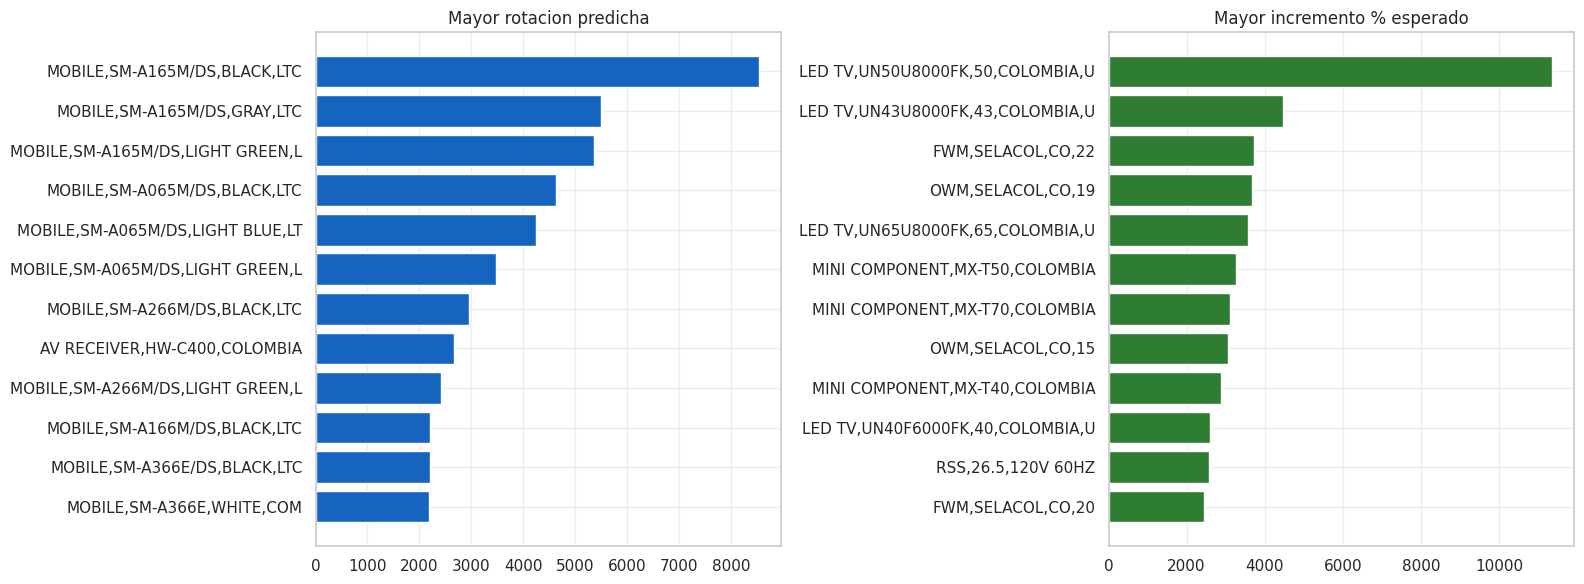

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/pred_productos.jpg


In [27]:
# Responde productos con mayor rotacion y crecimiento esperado.
last_3_months = sorted(monthly['Month_dt'].unique())[-3:]
hist_3m = (
    monthly[monthly['Month_dt'].isin(last_3_months)]
    .groupby(['Producto', 'Product_Type'], observed=True)['Cust_Sales']
    .mean()
    .reset_index(name='prom_3m')
)
pred_por_producto = df_pred_base.groupby(['Producto', 'Product_Type'], observed=True)['pred_ventas'].sum().reset_index()
df_ranking_prod = pred_por_producto.merge(hist_3m, on=['Producto', 'Product_Type'], how='left').fillna({'prom_3m': 0})
df_ranking_prod['incremento_abs'] = df_ranking_prod['pred_ventas'] - df_ranking_prod['prom_3m']
df_ranking_prod['incremento_pct'] = df_ranking_prod['incremento_abs'] / (df_ranking_prod['prom_3m'].abs() + 1) * 100

top_rotacion = df_ranking_prod.sort_values('pred_ventas', ascending=False).head(20)
top_crecimiento = df_ranking_prod[df_ranking_prod['prom_3m'] > 0].sort_values('incremento_pct', ascending=False).head(20)

print('A. Productos con mayor rotacion predicha')
display(top_rotacion.head(10))
print('C. Productos con mayor incremento esperado')
display(top_crecimiento.head(10))

top_rotacion.to_csv(output_path('top_productos_rotacion_predicha.csv'), index=False)
top_crecimiento.to_csv(output_path('top_productos_crecimiento_predicho.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_a = top_rotacion.head(12).copy()
plot_a['label'] = plot_a['Producto'].str.slice(0, 32)
axes[0].barh(plot_a['label'][::-1], plot_a['pred_ventas'][::-1], color='#1565C0')
axes[0].set_title('Mayor rotacion predicha')
plot_c = top_crecimiento.head(12).copy()
plot_c['label'] = plot_c['Producto'].str.slice(0, 32)
axes[1].barh(plot_c['label'][::-1], plot_c['incremento_pct'][::-1], color='#2E7D32')
axes[1].set_title('Mayor incremento % esperado')
savefig('pred_productos.jpg')
# A y C: productos con mayor rotacion e incremento esperado.

B. Clientes con tendencia a desaparecer


,Cliente,slope_6m,ventas_ultimo_mes,ventas_prom_6m,meses_sin_ventas_6m,pred_total,caida_vs_promedio,riesgo_churn
6,CUSTOMER18,-1106.400000,1022.0,3549.333333,0,1212.582520,-2336.750814,ALTO
13,CUSTOMER27,-284.628571,6280.0,12697.333333,0,2664.395752,-10032.937581,ALTO
30,CUSTOMER5,-179.514286,248.0,1376.500000,0,145.023636,-1231.476364,ALTO
55,CUSTOMER79,-102.400000,59.0,369.333333,0,59.594742,-309.738592,ALTO
8,CUSTOMER2,-101.342857,103.0,605.166667,0,152.818497,-452.348170,ALTO
64,CUSTOMER88,-38.314286,207.0,985.166667,0,192.975143,-792.191523,ALTO
26,CUSTOMER44,-27.657143,13.0,202.000000,0,34.217915,-167.782085,ALTO
20,CUSTOMER38,-23.400000,26.0,110.833333,0,15.100470,-95.732864,ALTO
27,CUSTOMER45,-22.571429,1.0,32.000000,0,4.381445,-27.618555,ALTO
23,CUSTOMER41,-21.371429,26.0,96.666667,0,33.072445,-63.594222,ALTO


D. Clientes que reduciran ventas


,Cliente,slope_6m,ventas_ultimo_mes,ventas_prom_6m,meses_sin_ventas_6m,pred_total,caida_vs_promedio,riesgo_churn
9,CUSTOMER20,-5276.028571,20172.0,50033.500000,0,28245.242188,-21788.257812,MEDIO
13,CUSTOMER27,-284.628571,6280.0,12697.333333,0,2664.395752,-10032.937581,ALTO
24,CUSTOMER42,-2383.600000,6417.0,22835.666667,0,13772.229492,-9063.437174,MEDIO
48,CUSTOMER7,-342.285714,30223.0,37810.333333,0,30092.441406,-7717.891927,MEDIO
12,CUSTOMER25,179.085714,2684.0,6245.666667,0,207.724579,-6037.942088,MEDIO
49,CUSTOMER70,-1230.914286,4840.0,11938.333333,0,6803.473633,-5134.859701,MEDIO
18,CUSTOMER35,-1005.742857,6148.0,11934.500000,0,7254.256348,-4680.243652,MEDIO
51,CUSTOMER73,-739.400000,3247.0,9206.166667,0,5086.942383,-4119.224284,MEDIO
25,CUSTOMER43,-900.457143,3257.0,7862.333333,0,4370.680664,-3491.652669,MEDIO
37,CUSTOMER57,-934.228571,840.0,5046.666667,0,1951.944092,-3094.722575,MEDIO


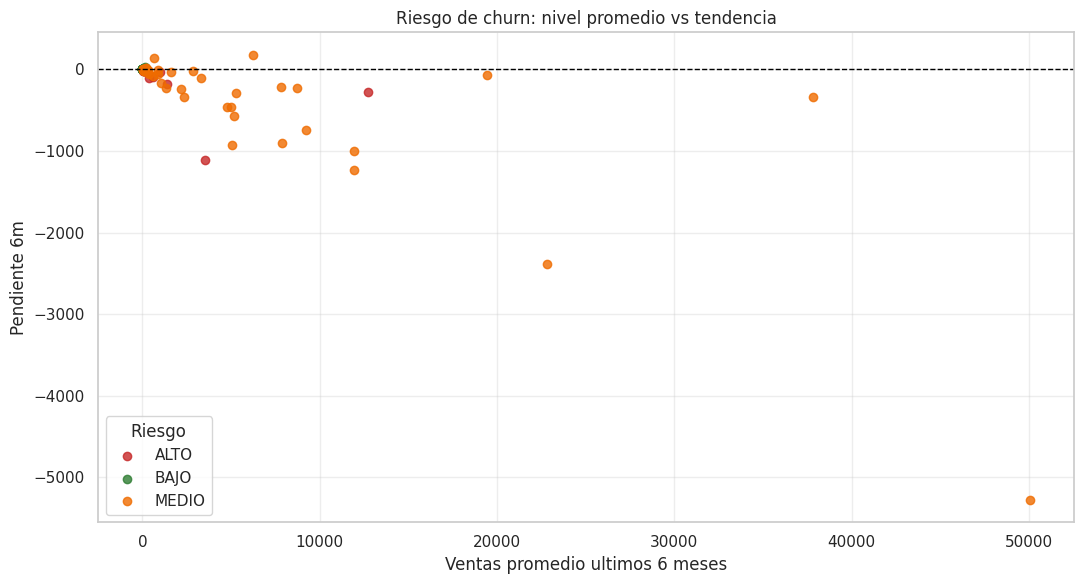

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/pred_churn_clientes.jpg


In [28]:
# Detecta clientes con posible caida o riesgo de churn.
last_6_months = sorted(monthly['Month_dt'].unique())[-6:]
ultimos_6m = monthly[monthly['Month_dt'].isin(last_6_months)].groupby(['Cliente','Month_dt'], observed=True)['Cust_Sales'].sum().reset_index()

tendencia_clientes = []
for cliente, grp_c in ultimos_6m.groupby('Cliente', observed=True):
    grp_c = grp_c.sort_values('Month_dt')
    x = np.arange(len(grp_c))
    y = grp_c['Cust_Sales'].values.astype(float)
    slope = np.polyfit(x, y, 1)[0] if len(x) >= 3 else 0.0
    tendencia_clientes.append({
        'Cliente': cliente,
        'slope_6m': slope,
        'ventas_ultimo_mes': y[-1] if len(y) else 0,
        'ventas_prom_6m': y.mean() if len(y) else 0,
        'meses_sin_ventas_6m': int((y == 0).sum())})

df_tendencia = pd.DataFrame(tendencia_clientes)
pred_por_cliente = df_pred_base.groupby('Cliente', observed=True)['pred_ventas'].sum().reset_index(name='pred_total')
df_tendencia = df_tendencia.merge(pred_por_cliente, on='Cliente', how='left').fillna({'pred_total': 0})
df_tendencia['caida_vs_promedio'] = df_tendencia['pred_total'] - df_tendencia['ventas_prom_6m']
df_tendencia['riesgo_churn'] = np.select(
    [
        (df_tendencia['slope_6m'] < 0) & (df_tendencia['pred_total'] < df_tendencia['ventas_prom_6m'] * 0.35),
        (df_tendencia['slope_6m'] < 0) | (df_tendencia['pred_total'] < df_tendencia['ventas_prom_6m'] * 0.70)
    ],
    ['ALTO', 'MEDIO'],
    default='BAJO')

print('B. Clientes con tendencia a desaparecer')
display(df_tendencia.sort_values(['riesgo_churn', 'slope_6m']).head(15))
print('D. Clientes que reduciran ventas')
display(df_tendencia.sort_values('caida_vs_promedio').head(15))

fig, ax = plt.subplots(figsize=(11, 6))
colors = {'ALTO': '#C62828', 'MEDIO': '#EF6C00', 'BAJO': '#2E7D32'}
for riesgo, grp_r in df_tendencia.groupby('riesgo_churn'):
    ax.scatter(grp_r['ventas_prom_6m'], grp_r['slope_6m'], label=riesgo, color=colors[riesgo], alpha=0.8)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Riesgo de churn: nivel promedio vs tendencia')
ax.set_xlabel('Ventas promedio ultimos 6 meses')
ax.set_ylabel('Pendiente 6m')
ax.legend(title='Riesgo')
savefig('pred_churn_clientes.jpg')
# B y D: clientes con tendencia a desaparecer o reducir ventas.

,Cliente,Producto,Product_Type,pred_ventas,Channel_Inv,Sell_in,periodo_predicho,inventario_negativo_flag,inventario_disponible,gap_demanda,gap_abs,cobertura_semanas,prioridad_despacho,recomendacion
43238,CUSTOMER24,"MOBILE,SM-A165M/DS,BLACK,LTC",MOBILE,2817.576904,11678.0,0.0,2025-09-01,0,11678.0,-8860.422852,8860.422852,17.821922,8860.422852,Monitorear
35306,CUSTOMER20,"MOBILE,SM-A065M,LIGHT GREEN,COM",MOBILE,1322.166260,9798.0,0.0,2025-09-01,0,9798.0,-8475.833984,8475.833984,31.864399,8475.833984,Monitorear
35264,CUSTOMER20,"MOBILE,SM-A065M,BLACK,COM",MOBILE,1474.093018,9581.0,0.0,2025-09-01,0,9581.0,-8106.907227,8106.907227,27.947422,8106.907227,Monitorear
35909,CUSTOMER20,"MOBILE,SM-A166M,LIGHT GREEN,COM",MOBILE,1676.987915,9329.0,0.0,2025-09-01,0,9329.0,-7652.012207,7652.012207,23.920073,7652.012207,Monitorear
178826,CUSTOMER56,"MOBILE,SM-A055M/DS,LIGHT GREEN,LTC",MOBILE,378.049713,7717.0,0.0,2025-09-01,0,7717.0,-7338.950195,7338.950195,87.764458,7338.950195,Monitorear
44555,CUSTOMER24,"MOBILE,SM-M556B/DS,BLACK,COO",MOBILE,769.596802,8092.0,0.0,2025-09-01,0,8092.0,-7322.403320,7322.403320,45.210243,7322.403320,Monitorear
35888,CUSTOMER20,"MOBILE,SM-A166M,GRAY,COM",MOBILE,1676.602295,8468.0,0.0,2025-09-01,0,8468.0,-6791.397461,6791.397461,21.717415,6791.397461,Monitorear
35867,CUSTOMER20,"MOBILE,SM-A166M,BLACK,COM",MOBILE,1630.634277,8093.0,0.0,2025-09-01,0,8093.0,-6462.365723,6462.365723,21.340765,6462.365723,Monitorear
260564,CUSTOMER70,"MOBILE,SM-A165M/DS,LIGHT GREEN,LTC",MOBILE,1257.841431,7428.0,0.0,2025-09-01,0,7428.0,-6170.158691,6170.158691,25.392159,6170.158691,Monitorear
43259,CUSTOMER24,"MOBILE,SM-A165M/DS,GRAY,LTC",MOBILE,2036.530762,7296.0,0.0,2025-09-01,0,7296.0,-5259.469238,5259.469238,15.404696,5259.469238,Monitorear


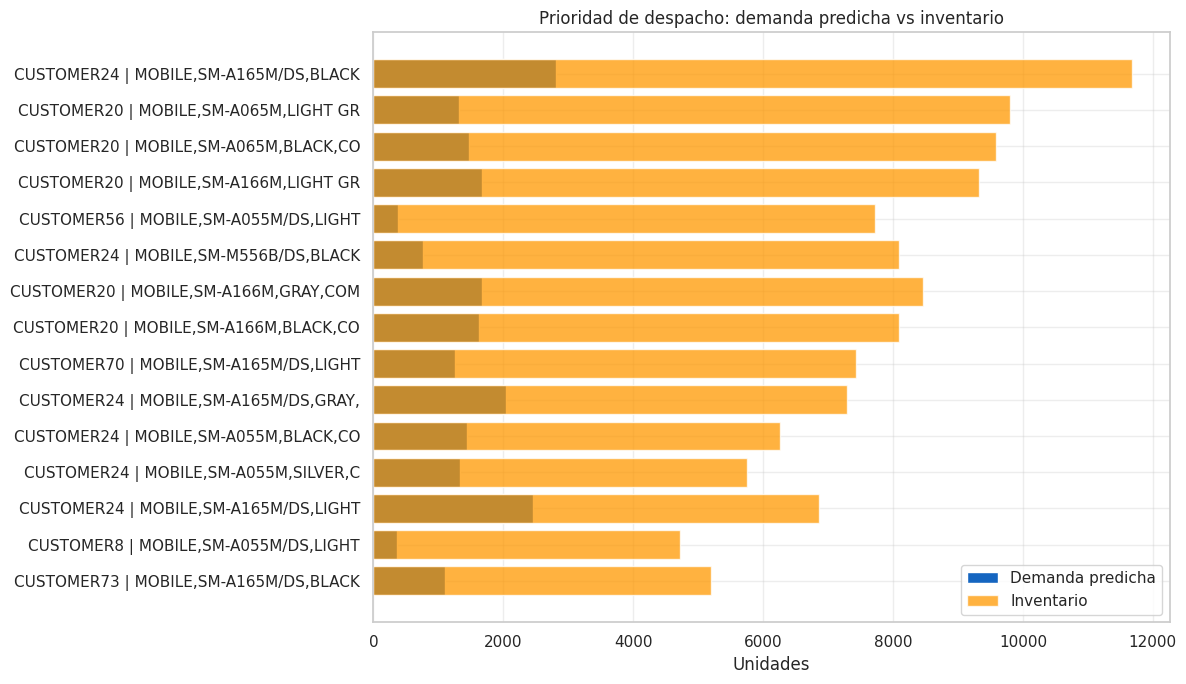

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/pred_despacho_urgente.jpg


In [29]:
# Calcula prioridad de despacho comparando prediccion contra inventario.
df_oportunidad = df_pred_base[['Cliente', 'Producto', 'Product_Type', 'pred_ventas', 'Channel_Inv', 'Sell_in', 'periodo_predicho']].copy()
df_oportunidad['inventario_negativo_flag'] = (df_oportunidad['Channel_Inv'] < 0).astype('int8')
# Sin dato de inventario, postura conservadora es asumir cero y priorizar el despacho.
df_oportunidad['inventario_disponible'] = df_oportunidad['Channel_Inv'].fillna(0)
df_oportunidad['gap_demanda'] = df_oportunidad['pred_ventas'] - df_oportunidad['inventario_disponible']
df_oportunidad['gap_abs'] = df_oportunidad['gap_demanda'].abs()
df_oportunidad['cobertura_semanas'] = df_oportunidad['inventario_disponible'] / ((df_oportunidad['pred_ventas'] / 4.3) + 0.01)
df_oportunidad['prioridad_despacho'] = df_oportunidad['gap_abs']
df_oportunidad['recomendacion'] = np.where(df_oportunidad['gap_demanda'] > 0, 'Despachar / reabastecer', 'Monitorear')

top_despachar = (
    df_oportunidad[df_oportunidad['pred_ventas'] > 0]
    .sort_values(['prioridad_despacho', 'pred_ventas'], ascending=[False, False])
    .head(30))
display(top_despachar.head(15))
df_oportunidad.sort_values(['prioridad_despacho', 'pred_ventas'], ascending=[False, False]).to_csv(output_path('prioridad_despacho.csv'), index=False)

plot_e = top_despachar.head(15).copy()
plot_e['label'] = plot_e['Cliente'].astype(str) + ' | ' + plot_e['Producto'].str.slice(0, 24)
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(plot_e['label'][::-1], plot_e['pred_ventas'][::-1], label='Demanda predicha', color='#1565C0')
ax.barh(plot_e['label'][::-1], plot_e['inventario_disponible'][::-1], label='Inventario', color='#FF9800', alpha=0.75)
ax.set_title('Prioridad de despacho: demanda predicha vs inventario')
ax.set_xlabel('Unidades')
ax.legend()
savefig('pred_despacho_urgente.jpg')
# E: a que cliente despachar mas producto y cual producto.

<center>
<font face="Cambria" size=5><b>7.5 Recomendaciones de inventario y despacho</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Comparar demanda esperada contra inventario disponible para priorizar acciones.

**Salida.** Recomendaciones de reabastecimiento por cliente y producto.

</font>

Productos que deberian reabastecerse primero:


,Producto,Product_Type,demanda_predicha,inventario_disponible,gap_total,clientes_en_riesgo
0,"MON,S22D310EAN,22,UNITED STATES,LV40/S22",MON,347.813690,21.0,326.813690,1
1,"OWM,SELACOL,CO,19",OWM,267.384644,42.0,225.384628,2
2,"OWM,SAMCOL,CO,19",OWM,309.325745,92.0,217.325729,2
3,"MINI COMPONENT,MX-T70,COLOMBIA",MINI COMPONENT,355.321716,159.0,196.321716,1
4,"OWM,SELACOL,CO,13",OWM,428.253540,259.0,169.253540,2
5,"FWM,SELACOL,CO,22",FWM,234.958389,67.0,167.958389,1
6,"RTF,264.0,120V 60HZ",RTF,380.648376,218.0,162.648376,2
7,"OWM,SAMCOL,CO,13",OWM,560.183472,413.0,147.183441,3
8,"TABLET,SM-X210,SILVER,COO",TABLET,141.619995,0.0,141.619995,2
9,"TABLET,SM-X210,GRAY,COO",TABLET,139.759521,0.0,139.759521,1


Clientes que requieren mayor despacho:


,Cliente,demanda_predicha,inventario_disponible,gap_total,productos_en_riesgo
0,CUSTOMER35,2552.663818,632.0,1920.663818,27
1,CUSTOMER27,529.314880,0.0,529.314880,7
2,CUSTOMER82,465.149139,91.0,374.149139,2
3,CUSTOMER74,986.473206,738.0,248.473206,2
4,CUSTOMER8,140.896637,0.0,140.896637,2
5,CUSTOMER7,696.756348,560.0,136.756378,2
6,CUSTOMER43,147.800278,19.0,128.800278,1
7,CUSTOMER39,452.299988,326.0,126.299973,2
8,CUSTOMER6,365.087616,243.0,122.087624,2
9,CUSTOMER87,102.068237,21.0,81.068237,1


Riesgo estimado de perdida por falta de inventario: 8,213 unidades
Demanda total monitoreada en la proyeccion: 160,641 unidades


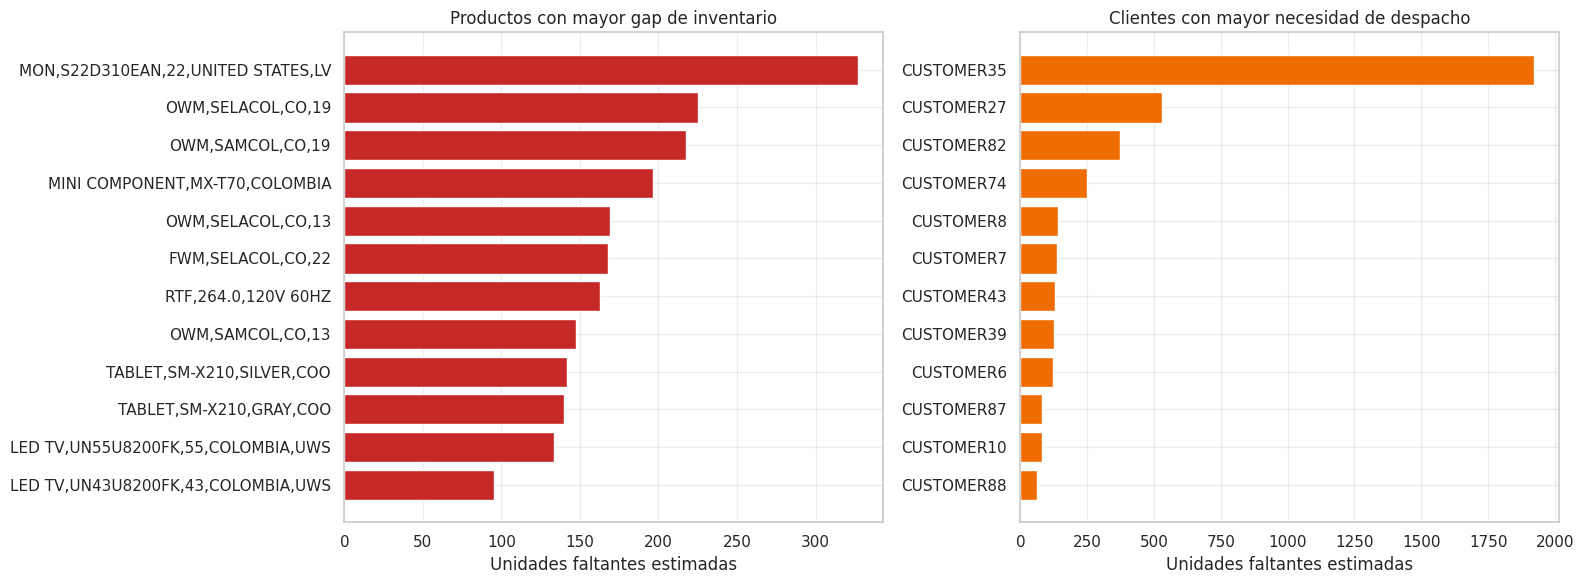

Guardado: /content/drive/MyDrive/Hackathon SIC 2026/outputs/imagenes/pred_20_recomendaciones_accionables.jpg


In [30]:
# Genera recomendaciones accionables de reabastecimiento.
recomendaciones_reabastecer = (
    df_oportunidad[df_oportunidad['gap_demanda'] > 0]
    .sort_values('prioridad_despacho', ascending=False)
    .head(50)
    .copy()
)
recomendaciones_clientes = (
    recomendaciones_reabastecer.groupby('Cliente', observed=True)
    .agg(
        demanda_predicha=('pred_ventas', 'sum'),
        inventario_disponible=('inventario_disponible', 'sum'),
        gap_total=('gap_demanda', 'sum'),
        productos_en_riesgo=('Producto', 'nunique')
    )
    .sort_values('gap_total', ascending=False)
    .reset_index()
)
recomendaciones_productos = (
    recomendaciones_reabastecer.groupby(['Producto','Product_Type'], observed=True)
    .agg(
        demanda_predicha=('pred_ventas', 'sum'),
        inventario_disponible=('inventario_disponible', 'sum'),
        gap_total=('gap_demanda', 'sum'),
        clientes_en_riesgo=('Cliente', 'nunique')
    )
    .sort_values('gap_total', ascending=False)
    .reset_index()
)

riesgo_perdida_ventas = df_oportunidad[df_oportunidad['gap_demanda'] > 0]['gap_demanda'].sum()
valor_unidades_monitorear = df_oportunidad['pred_ventas'].sum()

recomendaciones_reabastecer.to_csv(output_path('recomendaciones_reabastecer_cliente_producto.csv'), index=False)
recomendaciones_productos.to_csv(output_path('recomendaciones_productos_reabastecer.csv'), index=False)

print('Productos que deberian reabastecerse primero:')
display(recomendaciones_productos.head(10))
print('Clientes que requieren mayor despacho:')
display(recomendaciones_clientes.head(10))
print(f'Riesgo estimado de perdida por falta de inventario: {riesgo_perdida_ventas:,.0f} unidades')
print(f'Demanda total monitoreada en la proyeccion: {valor_unidades_monitorear:,.0f} unidades')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
prod_plot = recomendaciones_productos.head(12).copy()
prod_plot['label'] = prod_plot['Producto'].str.slice(0, 34)
axes[0].barh(prod_plot['label'][::-1], prod_plot['gap_total'][::-1], color='#C62828')
axes[0].set_title('Productos con mayor gap de inventario')
axes[0].set_xlabel('Unidades faltantes estimadas')

cli_plot = recomendaciones_clientes.head(12).copy()
axes[1].barh(cli_plot['Cliente'][::-1], cli_plot['gap_total'][::-1], color='#EF6C00')
axes[1].set_title('Clientes con mayor necesidad de despacho')
axes[1].set_xlabel('Unidades faltantes estimadas')
savefig('pred_20_recomendaciones_accionables.jpg')

<center>
<font face="Cambria" size=5><b>8. Exportables para dashboard y conclusiones</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Guardar archivos finales para el dashboard y la presentación.

**Organización.** CSV en `outputs/csv`, imágenes en `outputs/imagenes`, modelos y otros archivos en `outputs/otros`.

</font>

In [31]:
# Guarda modelo, predicciones y archivos listos para dashboard.
artifact_modelo = {
    'model': model,
    'features': FEATURES,
    'target_transform': globals().get('TARGET_TRANSFORM', 'none'),
    'label_encoders': {
        'Cliente': le_cliente,
        'Producto': le_producto,
        'Product_Type': le_tipo
    },
    'metrics': metrics,
    'modelo_ganador': globals().get('modelo_ganador_nombre', 'XGBoost')
}
joblib.dump(artifact_modelo, output_path('modelo_retailmind_ganador.joblib'))
joblib.dump(artifact_modelo, output_path('modelo_xgboost_retailmind.joblib'))

df_pred_base[['Cliente','Producto','Product_Type','periodo_predicho','months_gap_to_forecast','pred_ventas','Channel_Inv','Sell_in','mes','trimestre']].to_csv(
    output_path('predicciones_proximo_mes.csv'), index=False
)

dashboard_monthly = monthly.copy()
dashboard_monthly['Month_dt'] = dashboard_monthly['Month_dt'].astype(str)
dashboard_monthly.to_csv(output_path('dashboard_dataset_mensual.csv'), index=False)

print('Archivos clave para dashboard:')
for fname in [
    'dashboard_dataset_mensual.csv',
    'predicciones_proximo_mes.csv',
    'prioridad_despacho.csv',
    'analisis_churn_clientes.csv',
    'metricas_modelo.csv',
    'modelo_retailmind_ganador.joblib',
    'modelo_xgboost_retailmind.joblib'
]:
    print('-', output_path(fname))

Archivos clave para dashboard:
- /content/drive/MyDrive/Hackathon SIC 2026/outputs/csv/dashboard_dataset_mensual.csv
- /content/drive/MyDrive/Hackathon SIC 2026/outputs/csv/predicciones_proximo_mes.csv
- /content/drive/MyDrive/Hackathon SIC 2026/outputs/csv/prioridad_despacho.csv
- /content/drive/MyDrive/Hackathon SIC 2026/outputs/csv/analisis_churn_clientes.csv
- /content/drive/MyDrive/Hackathon SIC 2026/outputs/csv/metricas_modelo.csv
- /content/drive/MyDrive/Hackathon SIC 2026/outputs/otros/modelo_retailmind_ganador.joblib
- /content/drive/MyDrive/Hackathon SIC 2026/outputs/otros/modelo_xgboost_retailmind.joblib


<center>
<font face="Cambria" size=5><b>8.1 Interpretación por fase</b></font>
</center>

<font face="Cambria" size=3>

**Objetivo.** Traducir los resultados técnicos a mensajes claros para dirección comercial.

**Uso.** Esta tabla sirve como base para el dashboard y la presentación final.

</font>

In [32]:
# Traduce resultados tecnicos a una lectura ejecutiva por fase.
ganador = globals().get('modelo_ganador_nombre', 'XGBoost')
test_rows_interp = metrics[metrics['modelo'].str.contains('test', case=False, na=False)] if 'modelo' in metrics.columns else metrics
best_test_interp = test_rows_interp.sort_values(['WAPE_%', 'MAE']).iloc[0] if len(test_rows_interp) else metrics.iloc[0]
n_riesgo_alto_interp = int((df_tendencia['riesgo_churn'] == 'ALTO').sum()) if 'df_tendencia' in globals() else 0
pareto_msg_clientes = f'{n_clientes_80} clientes explican cerca del 80% de ventas'
pareto_msg_productos = f'{n_productos_80} productos explican cerca del 80% de ventas'

interpretacion_fases = pd.DataFrame([
    {
        'fase': 'Cargue y limpieza',
        'resultado_estadistico': f"{quality_summary['registros_long_reales']:,} registros reales; {quality_summary['ceros_futuros_no_observados']:,} ceros futuros excluidos",
        'interpretacion_negocio': 'Se evita tomar semanas no observadas como ventas cero. Esto protege al modelo de aprender una caida artificial de demanda.'
    },
    {
        'fase': 'EDA temporal',
        'resultado_estadistico': f"Periodo {monthly['Month_dt'].min().date()} a {monthly['Month_dt'].max().date()}; ventas totales {monthly['Cust_Sales'].sum():,.0f}",
        'interpretacion_negocio': 'Permite planear por calendario, detectar picos semanales y preparar inventario antes de los meses fuertes.'
    },
    {
        'fase': 'Clientes y productos',
        'resultado_estadistico': f"{pareto_msg_clientes}; {pareto_msg_productos}",
        'interpretacion_negocio': 'Si pocas cuentas o productos concentran ventas, deben tener seguimiento comercial prioritario y alertas tempranas.'
    },
    {
        'fase': 'Inventarios',
        'resultado_estadistico': f"{int((df_oportunidad['gap_demanda'] > 0).sum()):,} combinaciones con demanda proyectada mayor al inventario",
        'interpretacion_negocio': 'Estas combinaciones tienen riesgo de perdida de ventas por falta de producto y deben revisarse para despacho.'
    },
    {
        'fase': 'Modelado',
        'resultado_estadistico': f"Modelo ganador: {ganador}; MAE test {best_test_interp['MAE']:.2f}; WAPE {best_test_interp['WAPE_%']:.2f}%",
        'interpretacion_negocio': 'El modelo reduce error frente a reglas simples y permite priorizar acciones, no solo describir el pasado.'
    },
    {
        'fase': 'Recomendaciones',
        'resultado_estadistico': f"Riesgo de perdida estimado: {riesgo_perdida_ventas:,.0f} unidades; clientes alto churn: {n_riesgo_alto_interp}",
        'interpretacion_negocio': 'El equipo comercial puede combinar reabastecimiento, gestion de clientes en caida y foco en productos de alta rotacion.'
    }
])

display(interpretacion_fases)
interpretacion_fases.to_csv(output_path('interpretacion_ejecutiva_por_fase.csv'), index=False)

print('Resumen final:')
for _, row in interpretacion_fases.iterrows():
    print(f"- {row['fase']}: {row['interpretacion_negocio']}")

,fase,resultado_estadistico,interpretacion_negocio
0,Cargue y limpieza,"5,491,824 registros reales; 479,541 ceros futu...",Se evita tomar semanas no observadas como vent...
1,EDA temporal,Periodo 2023-01-01 a 2025-08-01; ventas totale...,"Permite planear por calendario, detectar picos..."
2,Clientes y productos,14 clientes explican cerca del 80% de ventas; ...,Si pocas cuentas o productos concentran ventas...
3,Inventarios,"8,957 combinaciones con demanda proyectada may...",Estas combinaciones tienen riesgo de perdida d...
4,Modelado,Modelo ganador: XGBoost; MAE test 21.37; WAPE ...,El modelo reduce error frente a reglas simples...
5,Recomendaciones,"Riesgo de perdida estimado: 8,213 unidades; cl...",El equipo comercial puede combinar reabastecim...


Resumen final:
- Cargue y limpieza: Se evita tomar semanas no observadas como ventas cero. Esto protege al modelo de aprender una caida artificial de demanda.
- EDA temporal: Permite planear por calendario, detectar picos semanales y preparar inventario antes de los meses fuertes.
- Clientes y productos: Si pocas cuentas o productos concentran ventas, deben tener seguimiento comercial prioritario y alertas tempranas.
- Inventarios: Estas combinaciones tienen riesgo de perdida de ventas por falta de producto y deben revisarse para despacho.
- Modelado: El modelo reduce error frente a reglas simples y permite priorizar acciones, no solo describir el pasado.
- Recomendaciones: El equipo comercial puede combinar reabastecimiento, gestion de clientes en caida y foco en productos de alta rotacion.


In [33]:
# Imprime conclusiones finales del proyecto.
test_rows = metrics[metrics['modelo'].str.contains('test', case=False, na=False)]
best_test = test_rows.iloc[0] if len(test_rows) else metrics.iloc[0]
baseline = metrics[metrics['modelo'] == 'Baseline lag_1'].iloc[0]
cliente_top = monthly.groupby('Cliente', observed=True)['Cust_Sales'].sum().idxmax()
producto_top = monthly.groupby('Producto', observed=True)['Cust_Sales'].sum().idxmax()
tipo_top = monthly.groupby('Product_Type', observed=True)['Cust_Sales'].sum().idxmax()
mejor_mes = estacionalidad.loc[estacionalidad['mean'].idxmax(), 'mes']
n_riesgo_alto = int((df_tendencia['riesgo_churn'] == 'ALTO').sum())
n_stockout_pred = int((df_oportunidad['gap_demanda'] > 0).sum())

print('=' * 80)
print('CONCLUSIONES - RETAILMIND CHALLENGE')
print('=' * 80)
print(f"Periodo analizado: {monthly['Month_dt'].min().date()} -> {monthly['Month_dt'].max().date()}")
print(f"Clientes: {monthly['Cliente'].nunique()} | Productos: {monthly['Producto'].nunique()} | Tipos: {monthly['Product_Type'].nunique()}")
print(f"Ventas totales Cust. Sales: {monthly['Cust_Sales'].sum():,.0f} unidades")
print(f"Tipo lider: {tipo_top} | Cliente top: {cliente_top} | Producto top: {producto_top[:55]}")
print(f"Mejor mes promedio: {int(mejor_mes)}")
print('\nModelo:')
print(f"Modelo ganador comparado: {globals().get('modelo_ganador_nombre', 'XGBoost')}")
print(f"MAE test modelo campeon: {best_test['MAE']:,.2f} | WAPE: {best_test['WAPE_%']:.2f}% | R2: {best_test['R2']:.4f}")
print(f"MAE baseline lag_1: {baseline['MAE']:,.2f}; mejora relativa MAE: {(1 - best_test['MAE']/baseline['MAE'])*100:.1f}%")
print(f"Variable mas influyente en el campeon: {importances.idxmax() if len(importances) else 'No disponible'}")
print('\nAlertas accionables:')
print(f"Clientes con riesgo ALTO de churn: {n_riesgo_alto}")
print(f"Combinaciones con demanda predicha superior al inventario: {n_stockout_pred:,}")
print('\nRecomendacion:')
print('Construir el dashboard con filtros por cliente, producto, tipo y periodo, usando los CSV exportados en outputs/.')

CONCLUSIONES - RETAILMIND CHALLENGE
Periodo analizado: 2023-01-01 -> 2025-08-01
Clientes: 98 | Productos: 2093 | Tipos: 76
Ventas totales Cust. Sales: 9,062,170 unidades
Tipo lider: MOBILE | Cliente top: CUSTOMER20 | Producto top: MOBILE,SM-A155M/DSN,BLACK,LTC
Mejor mes promedio: 7

Modelo:
Modelo ganador comparado: XGBoost
MAE test modelo campeon: 21.37 | WAPE: 58.03% | R2: 0.5901
MAE baseline lag_1: 34.67; mejora relativa MAE: 38.4%
Variable mas influyente en el campeon: lag_inv_1

Alertas accionables:
Clientes con riesgo ALTO de churn: 16
Combinaciones con demanda predicha superior al inventario: 8,957

Recomendacion:
Construir el dashboard con filtros por cliente, producto, tipo y periodo, usando los CSV exportados en outputs/.
